In [8]:
# ============================================================
# CELLULE 0 — A3 Sentiment : imports, style, palette, paths
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import spearmanr, kruskal
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

BASE = Path(".")
DATA = Path("..") / "data"
DATA_A1_OUT = Path("..") / "A1_temporal" / "outputs"
DATA_A2_OUT = Path("..") / "A2_topics" / "outputs"
DATA_A3 = BASE / "data"
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

COLORS = {
    "Brossat": "#E63946",
    "Chikirou": "#C1121F",
    "Belliard": "#2D6A4F",
    "Gregoire": "#E07A5F",
    "Bournazel": "#F4A261",
    "Dati": "#264653",
    "Knafo": "#6D4C41",
    "Mariani": "#1D3557",
}
ID_TO_KEY = {
    "david_belliard": "Belliard",
    "emmanuel_gregoire": "Gregoire",
    "ian_brossat": "Brossat",
    "pierre_yves_bournazel": "Bournazel",
    "rachida_dati": "Dati",
    "sarah_knafo": "Knafo",
    "sophia_chikirou": "Chikirou",
    "thierry_mariani": "Mariani",
}
KEY_TO_LABEL = {
    "Belliard": "Belliard (EELV)",
    "Gregoire": "Grégoire (PS)",
    "Brossat": "Brossat (PCF)",
    "Bournazel": "Bournazel (Horizons)",
    "Dati": "Dati (LR)",
    "Knafo": "Knafo (Reconquête)",
    "Chikirou": "Chikirou (LFI)",
    "Mariani": "Mariani (RN)",
}
ORDRE_IDEO = [
    "Brossat",
    "Chikirou",
    "Belliard",
    "Gregoire",
    "Bournazel",
    "Dati",
    "Knafo",
    "Mariani",
]

# Palette sentiment
SENT_COLORS = {
    "SOUTIEN": "#2D6A4F",
    "CRITIQUE": "#E9C46A",
    "IRONIE": "#F4A261",
    "HOSTILITE": "#E63946",
    "INCONNU": "#BBBBBB",
}
SENT_ORDER = ["SOUTIEN", "CRITIQUE", "IRONIE", "HOSTILITE", "INCONNU"]

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


def swiss_style(ax, title="", subtitle="", source="", grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.tick_params(colors="#333333", labelsize=9, length=3)
    ax.set_facecolor("white")
    ax.figure.set_facecolor("white")
    if title:
        ax.set_title(
            title, fontsize=12, fontweight="bold", loc="left", color="#1a1a1a", pad=10
        )
    if subtitle:
        ax.text(
            0,
            1.03,
            subtitle,
            transform=ax.transAxes,
            fontsize=8.5,
            color="#666666",
            va="bottom",
        )
    if source:
        ax.text(
            1,
            -0.13,
            source,
            transform=ax.transAxes,
            fontsize=7.5,
            color="#999999",
            ha="right",
            va="top",
        )
    if grid_axis:
        ax.grid(axis=grid_axis, color="#F0F0F0", linewidth=0.5, zorder=0)
    return ax


print("✓ Cellule 0 OK — A3 Sentiment configuré")
print(f"  Output : {OUT.resolve()}")

✓ Cellule 0 OK — A3 Sentiment configuré
  Output : D:\Users\Proprietaire\Desktop\Projet_perso\Presidentielle_tracker\final\A3_sentiment\outputs


CHARGEMENT replies_classified
  Shape           : (44599, 14)
  Timestamp OK    : 41586 / 44599 (93.2%)
  Timestamp NaT   : 3013
  year_week range : 2024-W51 → 2026-W08
  Platforms       : {'twitter': 41586, 'instagram': 3013}
  Sentiments      : {'CRITIQUE': 16898, 'SOUTIEN': 11839, 'HOSTILITE': 10614, 'IRONIE': 4740, 'INCONNU': 508}



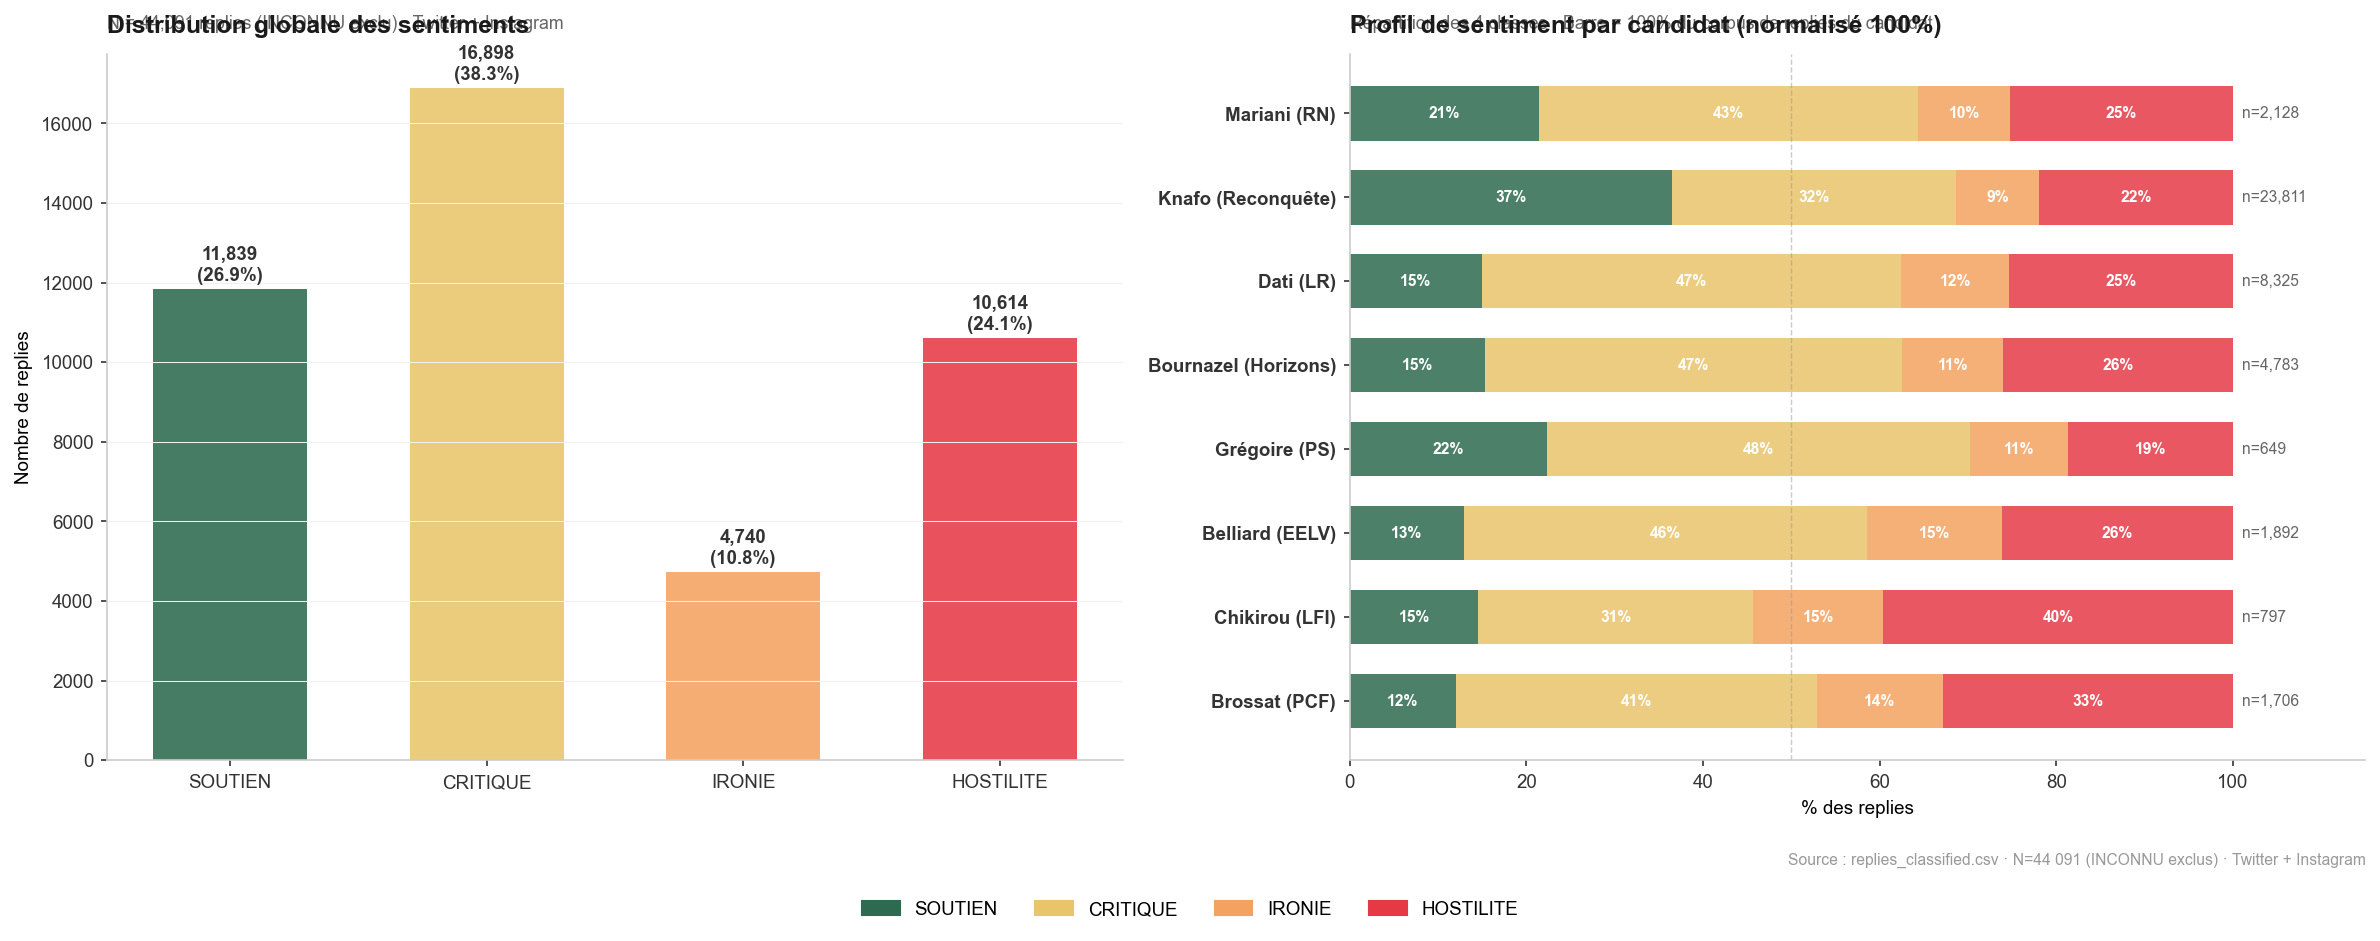

✓ Figure sauvegardée

DISTRIBUTION PAR CANDIDAT × PLATEFORME
  Brossat (PCF)                [twitter  ] n= 1172  SOUTIEN=7%  HOSTILITE=34%
  Brossat (PCF)                [instagram] n=  534  SOUTIEN=24%  HOSTILITE=30%
  Chikirou (LFI)               [twitter  ] n=  456  SOUTIEN=14%  HOSTILITE=38%
  Chikirou (LFI)               [instagram] n=  341  SOUTIEN=15%  HOSTILITE=43%
  Belliard (EELV)              [twitter  ] n= 1491  SOUTIEN=8%  HOSTILITE=28%
  Belliard (EELV)              [instagram] n=  401  SOUTIEN=31%  HOSTILITE=19%
  Grégoire (PS)                [twitter  ] n=  252  SOUTIEN=8%  HOSTILITE=27%
  Grégoire (PS)                [instagram] n=  397  SOUTIEN=31%  HOSTILITE=13%
  Bournazel (Horizons)         [twitter  ] n= 4651  SOUTIEN=15%  HOSTILITE=26%
  Bournazel (Horizons)         [instagram] n=  132  SOUTIEN=36%  HOSTILITE=17%
  Dati (LR)                    [twitter  ] n= 8160  SOUTIEN=15%  HOSTILITE=25%
  Dati (LR)                    [instagram] n=  165  SOUTIEN=29%  HOSTILIT

In [9]:
# ============================================================
# CELLULE 1 — Chargement replies_classified + distribution
#             par classe, par candidat, par plateforme
# ============================================================

rp = pd.read_csv(DATA / "replies_classified.csv")
rp["key"] = rp["candidate_id"].map(ID_TO_KEY)

# Parsing timestamp : 'Jan 21, 2026 · 6:55 PM UTC'
rp["ts_parsed"] = pd.to_datetime(
    rp["timestamp"].str.replace(" · ", " ", regex=False),
    format="%b %d, %Y %I:%M %p UTC",
    utc=True,
    errors="coerce",
)
ts_ok = rp["ts_parsed"].notna().sum()
ts_nok = rp["ts_parsed"].isna().sum()

# year_week — NaT reste NaN (pas de strftime sur NaT)
rp["year_week"] = rp["ts_parsed"].dt.strftime("%G-W%V")  # NaT → NaN str

# ── FIX : dropna() pour les stats sur year_week ──────────────
yw_valid = rp["year_week"].dropna()

print("=" * 60)
print("CHARGEMENT replies_classified")
print("=" * 60)
print(f"  Shape           : {rp.shape}")
print(f"  Timestamp OK    : {ts_ok} / {len(rp)} ({100*ts_ok/len(rp):.1f}%)")
print(f"  Timestamp NaT   : {ts_nok}")
print(f"  year_week range : {yw_valid.min()} → {yw_valid.max()}")
print(f"  Platforms       : {rp['platform'].value_counts().to_dict()}")
print(f"  Sentiments      : {rp['sentiment'].value_counts().to_dict()}")
print()

# ── Figure : 2 panels ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel gauche : distribution globale
ax_glob = axes[0]
sent_counts = rp[rp["sentiment"] != "INCONNU"]["sentiment"].value_counts()
sent_counts = sent_counts.reindex([s for s in SENT_ORDER if s != "INCONNU"])
colors_bar = [SENT_COLORS[s] for s in sent_counts.index]
ax_glob.bar(
    range(len(sent_counts)), sent_counts.values, color=colors_bar, alpha=0.88, width=0.6
)
for i, (sent, n) in enumerate(sent_counts.items()):
    ax_glob.text(
        i,
        n + 200,
        f"{n:,}\n({100*n/sent_counts.sum():.1f}%)",
        ha="center",
        fontsize=9,
        color="#333333",
        fontweight="bold",
    )
ax_glob.set_xticks(range(len(sent_counts)))
ax_glob.set_xticklabels(sent_counts.index, fontsize=10)
swiss_style(
    ax_glob,
    title="Distribution globale des sentiments",
    subtitle=f"N = {sent_counts.sum():,} replies (INCONNU exclu) · Twitter + Instagram",
    grid_axis="y",
)
ax_glob.set_ylabel("Nombre de replies", fontsize=9)

# Panel droit : distribution empilée 100% par candidat
ax_cand = axes[1]
for i, key in enumerate(ORDRE_IDEO):
    sub = rp[(rp["key"] == key) & (rp["sentiment"] != "INCONNU")]
    total = len(sub)
    left = 0
    for sent in ["SOUTIEN", "CRITIQUE", "IRONIE", "HOSTILITE"]:
        n = (sub["sentiment"] == sent).sum()
        pct = n / total * 100 if total > 0 else 0
        ax_cand.barh(
            i, pct, left=left, color=SENT_COLORS[sent], alpha=0.85, height=0.65
        )
        if pct > 6:
            ax_cand.text(
                left + pct / 2,
                i,
                f"{pct:.0f}%",
                ha="center",
                va="center",
                fontsize=7.5,
                color="white",
                fontweight="bold",
            )
        left += pct
    ax_cand.text(101, i, f"n={total:,}", va="center", fontsize=7.5, color="#666")

ax_cand.set_yticks(range(len(ORDRE_IDEO)))
ax_cand.set_yticklabels([KEY_TO_LABEL[k] for k in ORDRE_IDEO], fontsize=9)
for i, key in enumerate(ORDRE_IDEO):
    ax_cand.get_yticklabels()[i].set_color(COLORS[key])
    ax_cand.get_yticklabels()[i].set_fontweight("bold")
ax_cand.set_xlim(0, 115)
ax_cand.axvline(50, color="#999", lw=0.7, ls="--", alpha=0.5)
swiss_style(
    ax_cand,
    title="Profil de sentiment par candidat (normalisé 100%)",
    subtitle="Répartition des 4 classes · Barre = 100% du corpus de replies du candidat",
    source="Source : replies_classified.csv · N=44 091 (INCONNU exclus) · Twitter + Instagram",
    grid_axis=None,
)
ax_cand.set_xlabel("% des replies", fontsize=9)

legend_handles = [
    mpatches.Patch(color=SENT_COLORS[s], label=s)
    for s in ["SOUTIEN", "CRITIQUE", "IRONIE", "HOSTILITE"]
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
plt.savefig(OUT / "A3_C1_distribution_sentiment.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Sortie texte ──────────────────────────────────────────────
print("✓ Figure sauvegardée")
print("\n" + "=" * 60)
print("DISTRIBUTION PAR CANDIDAT × PLATEFORME")
print("=" * 60)
for key in ORDRE_IDEO:
    for plat in ["twitter", "instagram"]:
        sub = rp[
            (rp["key"] == key)
            & (rp["platform"] == plat)
            & (rp["sentiment"] != "INCONNU")
        ]
        if len(sub) == 0:
            continue
        host_pct = 100 * (sub["sentiment"] == "HOSTILITE").sum() / len(sub)
        sout_pct = 100 * (sub["sentiment"] == "SOUTIEN").sum() / len(sub)
        print(
            f"  {KEY_TO_LABEL[key]:<28} [{plat:<9}] n={len(sub):>5}"
            f"  SOUTIEN={sout_pct:.0f}%  HOSTILITE={host_pct:.0f}%"
        )

print("\n" + "=" * 60)
print("NOTE STRUCTURELLE")
print("=" * 60)
knafo_n = (rp["key"] == "Knafo").sum()
print(f"  Knafo    : {knafo_n:,} replies ({100*knafo_n/len(rp):.0f}% du corpus total)")
print(f"  Grégoire : {(rp['key']=='Gregoire').sum():,} replies")
print(f"  → Déséquilibre extrême : analyses par candidat à interpréter avec les n")
print(f"\n  Replies sans timestamp parsé : {ts_nok}")
if ts_nok > 0:
    print(f"  Exemples : {rp[rp['ts_parsed'].isna()]['timestamp'].head(3).tolist()}")

# Sauvegarde pour cellules suivantes
rp.to_parquet(OUT / "A3_replies_enriched.parquet", index=False)
print(f"\n✓ Replies enrichies sauvegardées → {OUT/'A3_replies_enriched.parquet'}")

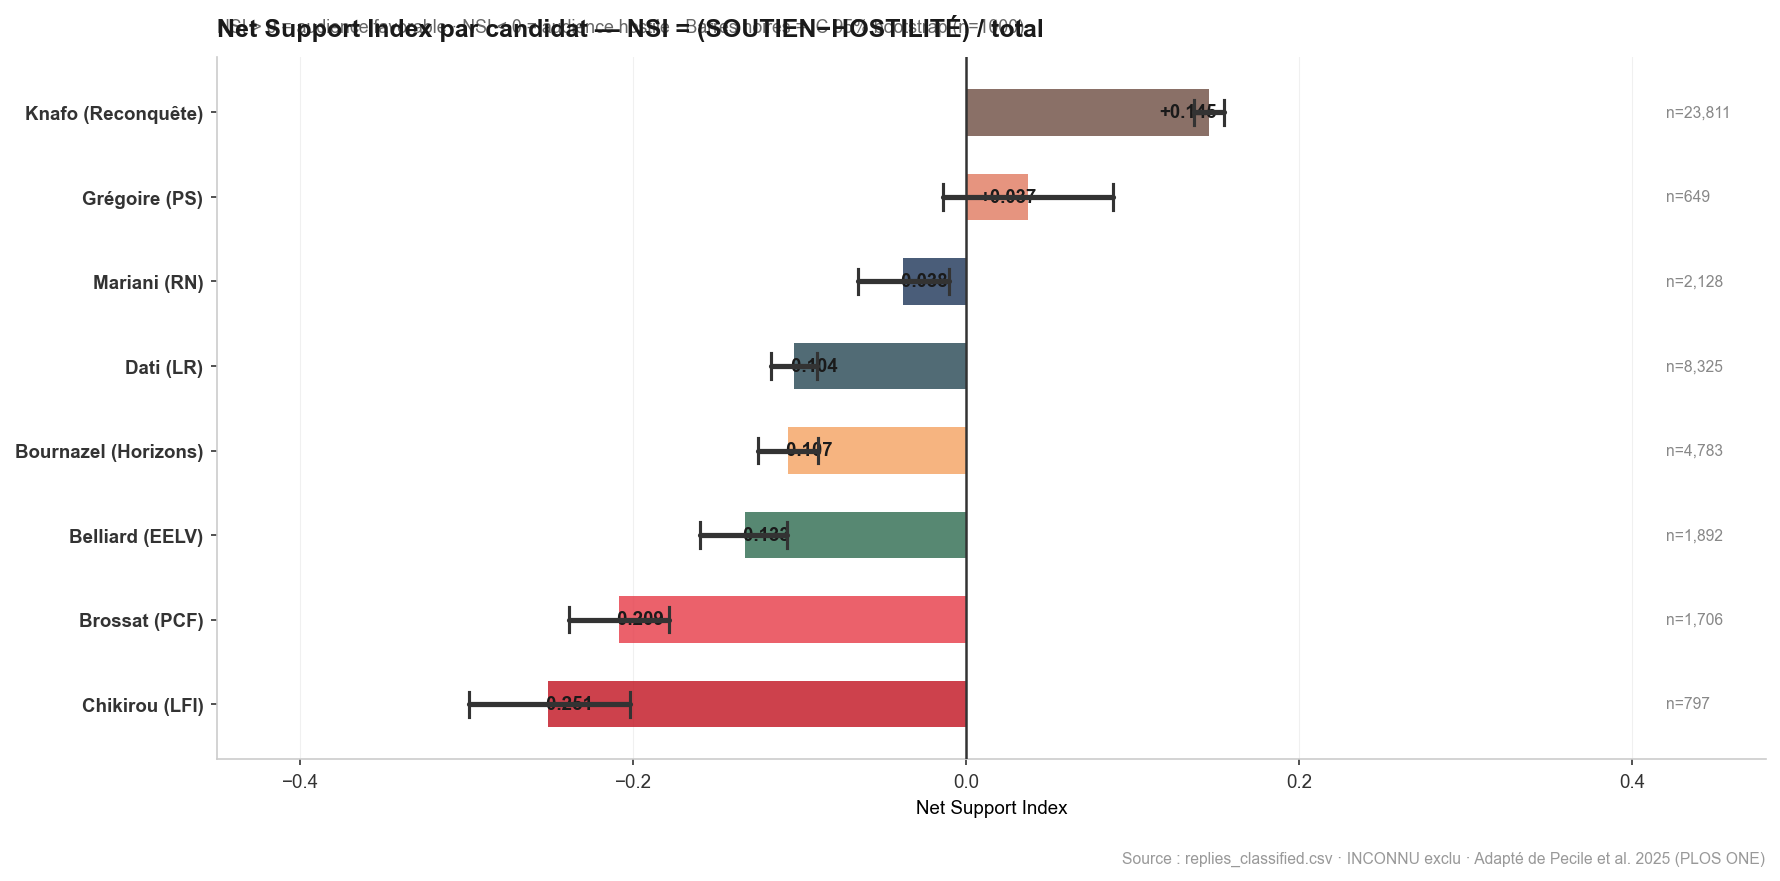

✓ Figure sauvegardée

NET SUPPORT INDEX — résultats complets
Candidat                         NSI             IC 95%       n   SOUTIEN   HOSTILITÉ
-------------------------------------------------------------------------------------
  Knafo (Reconquête)          +0.145  [+0.137; +0.155]   23,811    8,697 (37%)    5,233 (22%)
  Grégoire (PS)               +0.037  [-0.014; +0.088]      649      145 (22%)      121 (19%)
  Mariani (RN)                -0.038  [-0.065; -0.010]    2,128      456 (21%)      537 (25%)
  Dati (LR)                   -0.104  [-0.117; -0.089]    8,325    1,245 (15%)    2,108 (25%)
  Bournazel (Horizons)        -0.107  [-0.125; -0.089]    4,783      731 (15%)    1,243 (26%)
  Belliard (EELV)             -0.133  [-0.160; -0.108]    1,892      244 (13%)      495 (26%)
  Brossat (PCF)               -0.209  [-0.239; -0.179]    1,706      205 (12%)      561 (33%)
  Chikirou (LFI)              -0.251  [-0.299; -0.202]      797      116 (15%)      316 (40%)

✓ Export NSI →

In [10]:
# ============================================================
# CELLULE 2 — Net Support Index (NSI) par candidat
#             + intervalles de confiance bootstrap (n=1000)
# ============================================================

rp_clean = rp[rp["sentiment"] != "INCONNU"].copy()


def compute_nsi(series):
    total = len(series)
    if total == 0:
        return np.nan
    n_sout = (series == "SOUTIEN").sum()
    n_host = (series == "HOSTILITE").sum()
    n_crit = (series == "CRITIQUE").sum()
    n_iron = (series == "IRONIE").sum()
    return (n_sout - n_host) / (n_sout + n_host + n_crit + n_iron)


def bootstrap_nsi(series, n_boot=1000, ci=0.95):
    nsi_vals = []
    arr = series.values
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        sample = rng.choice(arr, size=len(arr), replace=True)
        n_s = (sample == "SOUTIEN").sum()
        n_h = (sample == "HOSTILITE").sum()
        n_c = (sample == "CRITIQUE").sum()
        n_i = (sample == "IRONIE").sum()
        denom = n_s + n_h + n_c + n_i
        nsi_vals.append((n_s - n_h) / denom if denom else np.nan)
    nsi_vals = np.array(nsi_vals)
    lo = np.nanpercentile(nsi_vals, (1 - ci) / 2 * 100)
    hi = np.nanpercentile(nsi_vals, (1 + ci) / 2 * 100)
    return lo, hi


# ── Calcul NSI + CI ──────────────────────────────────────────
nsi_results = []
for key in ORDRE_IDEO:
    sub = rp_clean[rp_clean["key"] == key]["sentiment"]
    nsi = compute_nsi(sub)
    lo, hi = bootstrap_nsi(sub)
    nsi_results.append(
        {
            "key": key,
            "label": KEY_TO_LABEL[key],
            "nsi": nsi,
            "ci_lo": lo,
            "ci_hi": hi,
            "n": len(sub),
            "n_host": (sub == "HOSTILITE").sum(),
            "n_sout": (sub == "SOUTIEN").sum(),
            "host_pct": 100 * (sub == "HOSTILITE").sum() / len(sub),
        }
    )
nsi_df = pd.DataFrame(nsi_results).sort_values("nsi")

# ── Figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for i, row in enumerate(nsi_df.itertuples()):
    color = COLORS[row.key]
    # Barre NSI
    ax.barh(i, row.nsi, color=color, alpha=0.80, height=0.55, zorder=3)
    # CI bootstrap
    ax.plot(
        [row.ci_lo, row.ci_hi],
        [i, i],
        color="#333333",
        lw=2.5,
        solid_capstyle="round",
        zorder=4,
    )
    ax.plot([row.ci_lo, row.ci_lo], [i - 0.15, i + 0.15], "#333333", lw=1.5, zorder=4)
    ax.plot([row.ci_hi, row.ci_hi], [i - 0.15, i + 0.15], "#333333", lw=1.5, zorder=4)
    # Valeur
    ha = "left" if row.nsi < 0 else "right"
    offset = 0.005 if row.nsi >= 0 else -0.005
    ax.text(
        row.nsi + offset,
        i,
        f"{row.nsi:+.3f}",
        va="center",
        ha=ha,
        fontsize=9,
        color="#1a1a1a",
        fontweight="bold",
    )
    # n= à droite
    ax.text(0.42, i, f"n={row.n:,}", va="center", fontsize=7.5, color="#888")

ax.axvline(0, color="#333333", lw=1.2, zorder=5)
ax.set_yticks(range(len(nsi_df)))
ax.set_yticklabels([KEY_TO_LABEL[k] for k in nsi_df["key"]], fontsize=9.5)
for i, key in enumerate(nsi_df["key"]):
    ax.get_yticklabels()[i].set_color(COLORS[key])
    ax.get_yticklabels()[i].set_fontweight("bold")

swiss_style(
    ax,
    title="Net Support Index par candidat — NSI = (SOUTIEN−HOSTILITÉ) / total",
    subtitle="NSI > 0 = audience favorable · NSI < 0 = audience hostile · Barres noires = IC 95% bootstrap (n=1000)",
    source="Source : replies_classified.csv · INCONNU exclu · Adapté de Pecile et al. 2025 (PLOS ONE)",
    grid_axis="x",
)
ax.set_xlabel("Net Support Index", fontsize=9)
ax.set_xlim(-0.45, 0.48)

plt.tight_layout()
plt.savefig(OUT / "A3_C2_NSI.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Sortie texte ──────────────────────────────────────────────
print("✓ Figure sauvegardée")
print("\n" + "=" * 60)
print("NET SUPPORT INDEX — résultats complets")
print("=" * 60)
print(
    f"{'Candidat':<28} {'NSI':>7} {'IC 95%':>18} {'n':>7} {'SOUTIEN':>9} {'HOSTILITÉ':>11}"
)
print("-" * 85)
for _, row in nsi_df.sort_values("nsi", ascending=False).iterrows():
    print(
        f"  {KEY_TO_LABEL[row['key']]:<26} {row['nsi']:>+7.3f}"
        f"  [{row['ci_lo']:+.3f}; {row['ci_hi']:+.3f}]"
        f"  {row['n']:>7,}  {row['n_sout']:>7,} ({row['n_sout']/row['n']*100:.0f}%)"
        f"  {row['n_host']:>7,} ({row['host_pct']:.0f}%)"
    )

# Export pour A7
nsi_df.to_csv(OUT / "A3_nsi_by_candidate.csv", index=False)
print(f"\n✓ Export NSI → {OUT / 'A3_nsi_by_candidate.csv'}")

Coverage mapping :
  Candidat                      sem   n_replies
  ----------------------------------------------
  Belliard (EELV)                19         405
  Bournazel (Horizons)           14         132
  Brossat (PCF)                  18         542
  Chikirou (LFI)                 18         343
  Dati (LR)                      21         164
  Grégoire (PS)                  19         397
  Knafo (Reconquête)             25         947
  Mariani (RN)                   10          82

  Anomalies A1 : 25 semaines / 35 evenements


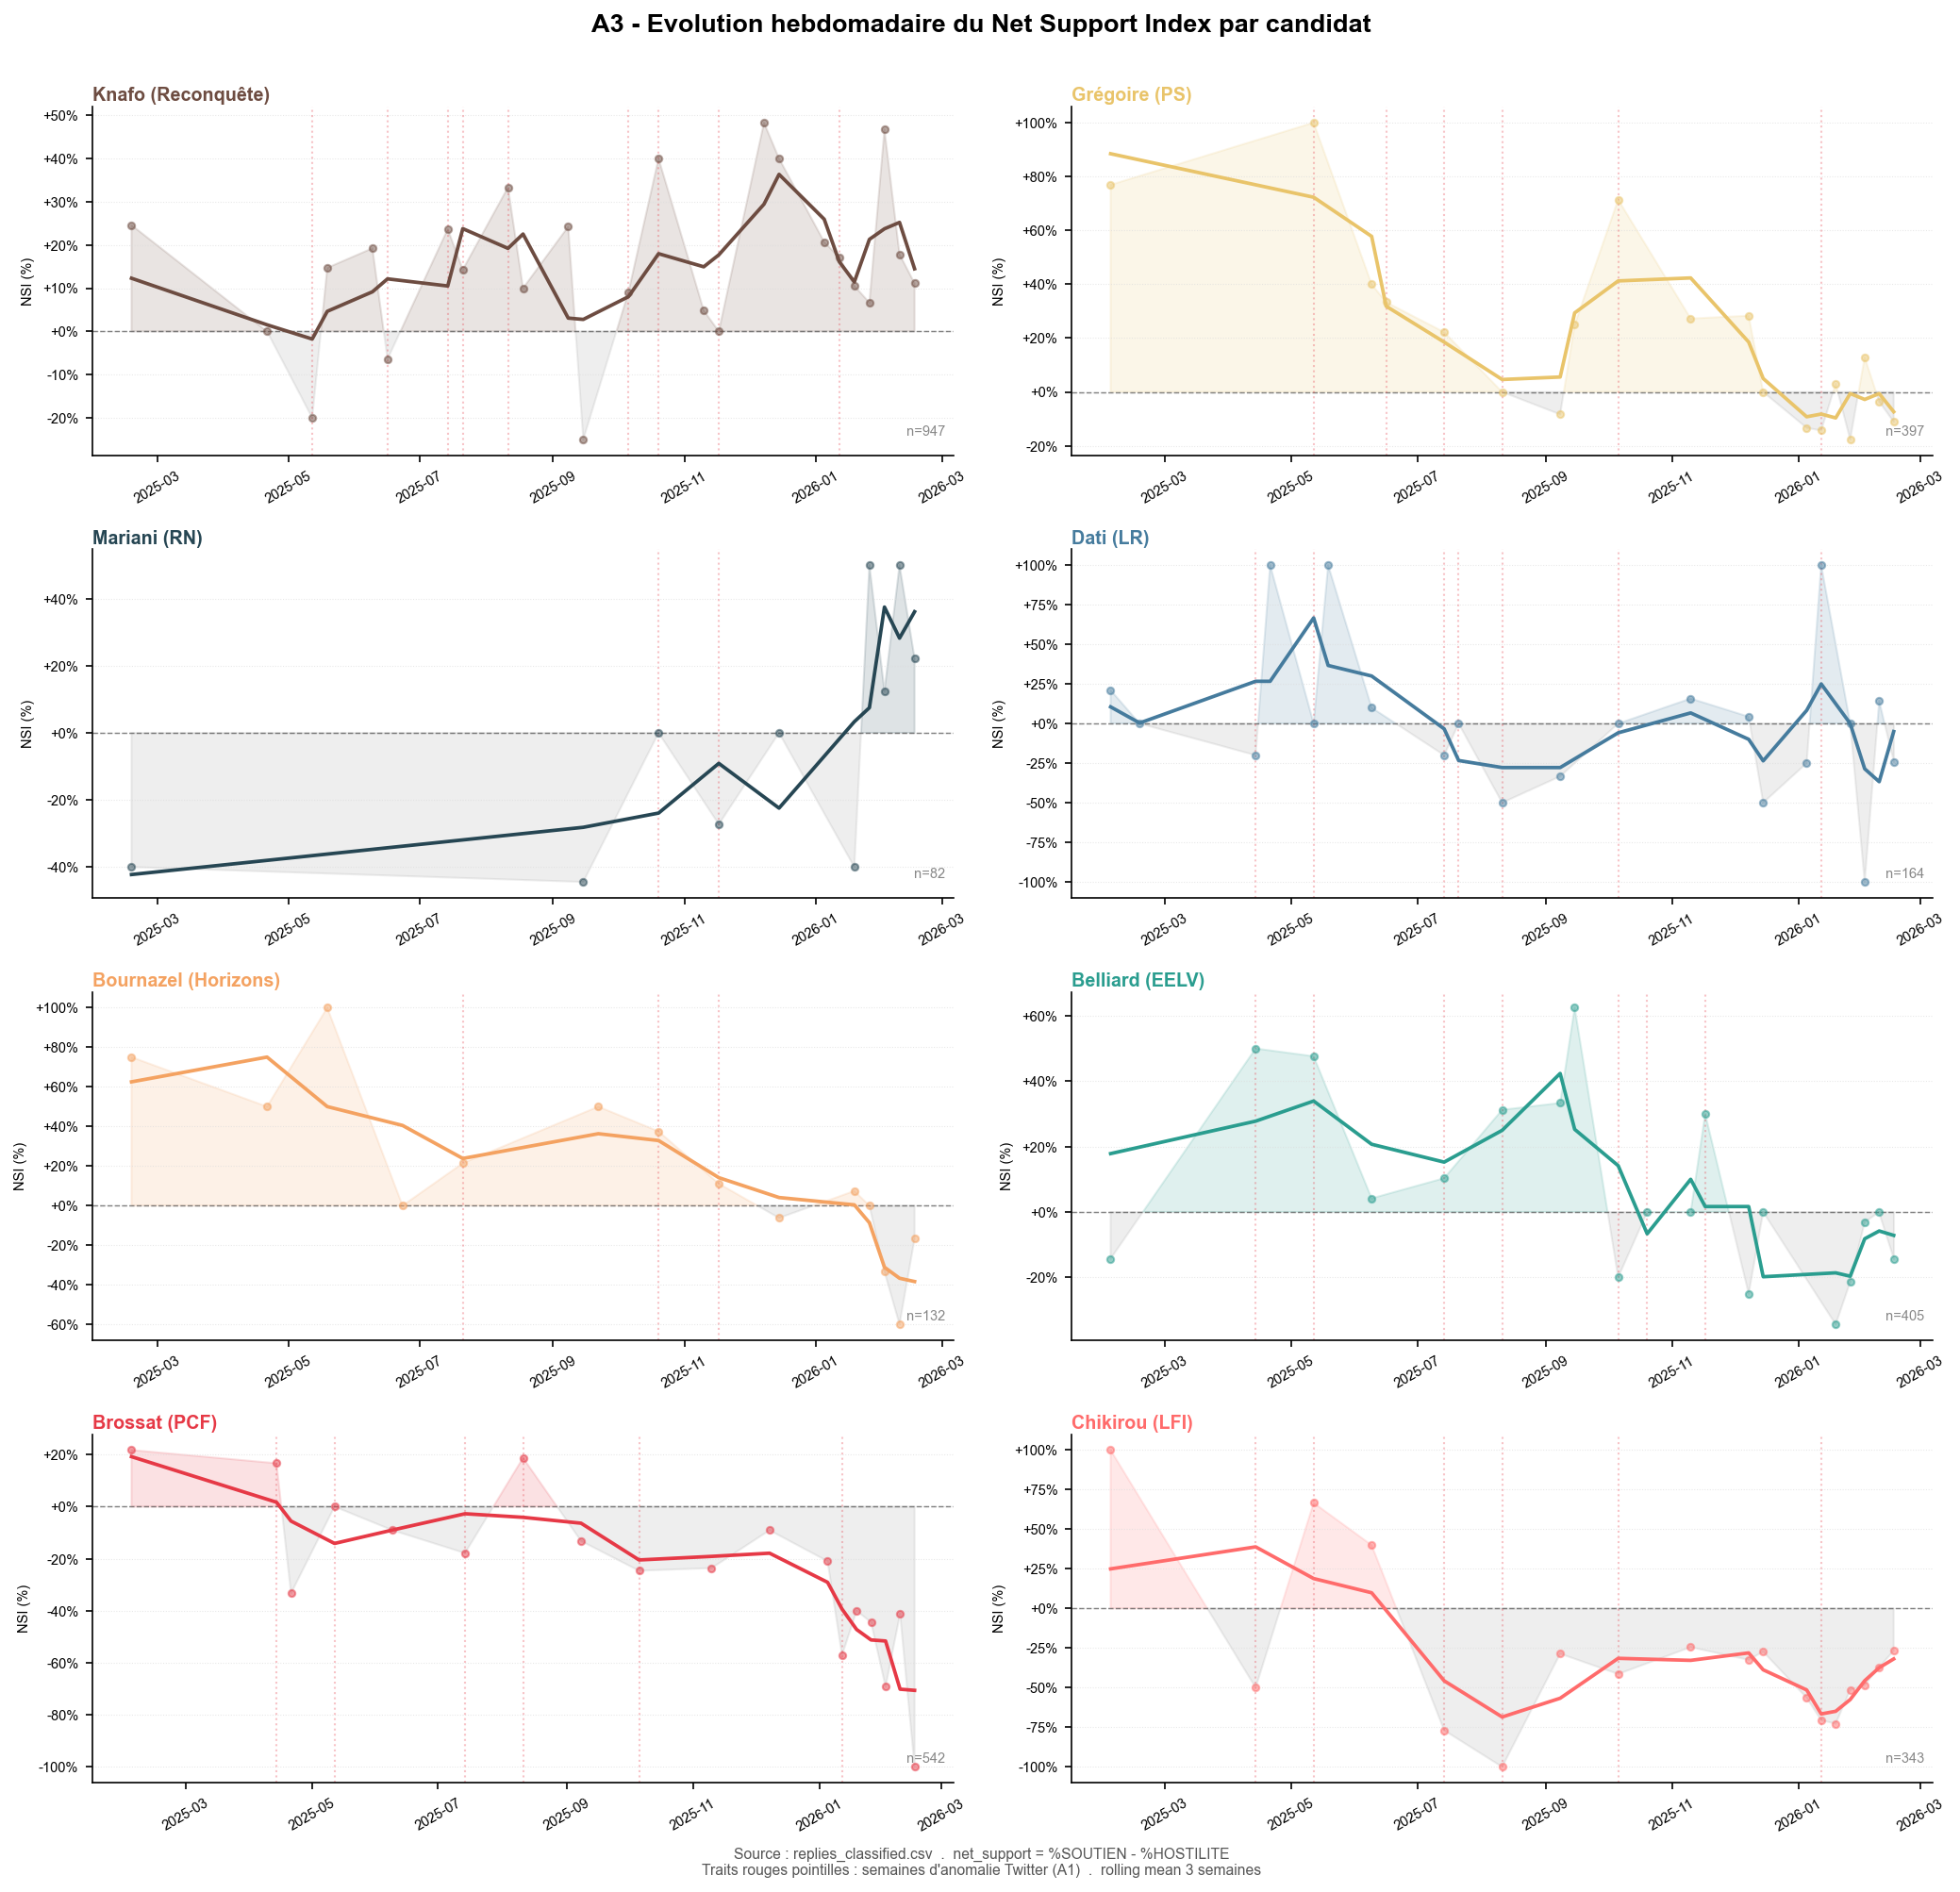

Figure C3 sauvegardee


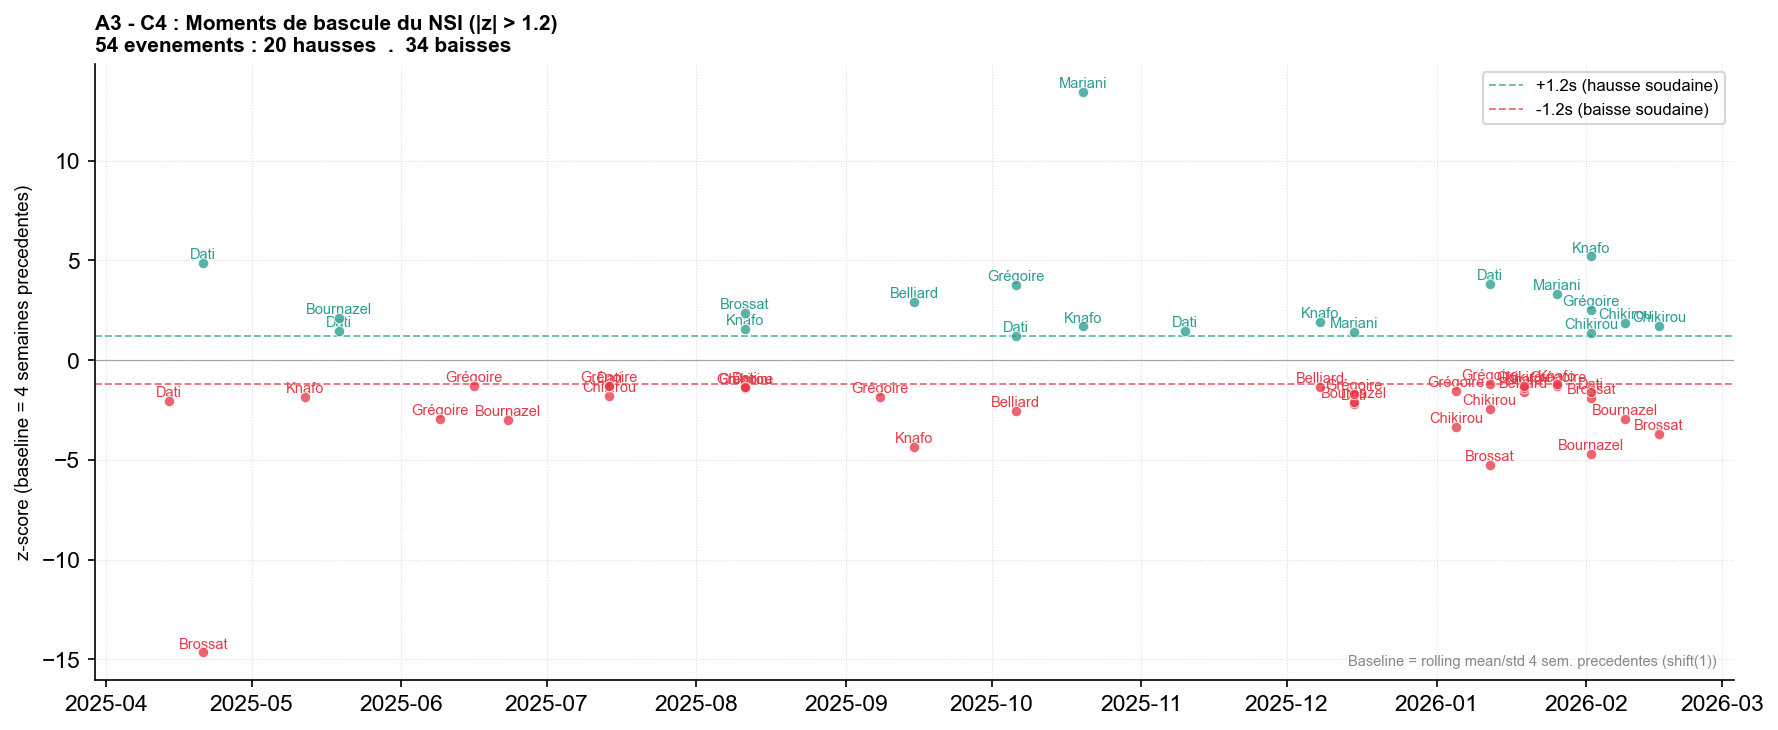

Figure C4 sauvegardee

C4 - MOMENTS DE BASCULE (|z| > 1.2) - 54 evenements
  Candidat               Semaine           NSI        z  Direction
  ----------------------------------------------------------
  Brossat (PCF)          2025-W17       -33.3%   -14.65   Baisse
  Mariani (RN)           2025-W43        +0.0%   +13.45   Hausse
  Brossat (PCF)          2026-W03       -57.1%    -5.25   Baisse
  Knafo (Reconquête)     2026-W06       +46.7%    +5.20   Hausse
  Dati (LR)              2025-W17      +100.0%    +4.85   Hausse
  Bournazel (Horizons)   2026-W06       -33.3%    -4.70   Baisse
  Knafo (Reconquête)     2025-W38       -25.0%    -4.35   Baisse
  Dati (LR)              2026-W03      +100.0%    +3.83   Hausse
  Grégoire (PS)          2025-W41       +71.4%    +3.76   Hausse
  Brossat (PCF)          2026-W08      -100.0%    -3.71   Baisse
  Chikirou (LFI)         2026-W02       -56.4%    -3.36   Baisse
  Mariani (RN)           2026-W05       +50.0%    +3.32   Hausse
  Bournazel (Hori

In [11]:
# ============================================================
# A3 · Cellule 3 — NSI Timeline (C3) + Moments de bascule (C4)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import unicodedata
from pathlib import Path
from scipy import stats

BASE    = Path('.')
DATA_A3 = BASE / 'data'
A1_OUT  = Path('..') / 'A1_temporal' / 'outputs'
OUT     = BASE / 'outputs'
OUT.mkdir(exist_ok=True)

COLORS = {
    'Brossat':  '#E63946', 'Chikirou': '#FF6B6B', 'Belliard': '#2A9D8F',
    'Gregoire': '#E9C46A', 'Bournazel':'#F4A261', 'Dati':     '#457B9D',
    'Knafo':    '#6D4C41', 'Mariani':  '#264653'
}
ID_TO_KEY = {
    'pierre_yves_brossat':'Brossat', 'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',     'lea_gregoire':'Gregoire',
    'victor_bournazel':'Bournazel',  'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',           'thierry_mariani':'Mariani'
}
SHORT = {
    'Brossat':'Brossat (PCF)',         'Chikirou':'Chikirou (LFI)',
    'Belliard':'Belliard (EELV)',      'Gregoire':'Grégoire (PS)',
    'Bournazel':'Bournazel (Horizons)','Dati':'Dati (LR)',
    'Knafo':'Knafo (Reconquête)',      'Mariani':'Mariani (RN)'
}

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s))
                   if unicodedata.category(c) != 'Mn')

# ── Load + mapping robuste (candidate_id puis candidate column) ───────────────
sw = pd.read_csv(DATA_A3 / 'sentiment_weekly_4class.csv')
sw['key'] = sw['candidate_id'].map(ID_TO_KEY)
unmapped  = sw['key'].isna()
if unmapped.any():
    sw.loc[unmapped, 'key'] = sw.loc[unmapped, 'candidate'].apply(strip_accents)

print("Coverage mapping :")
print(f"  {'Candidat':<28} {'sem':>4}  {'n_replies':>10}")
print("  " + "-" * 46)
for k in sorted(sw['key'].dropna().unique()):
    sub = sw[sw['key'] == k]
    print(f"  {SHORT.get(k, k):<28} {len(sub):>4}  {sub['n_replies'].sum():>10,}")
if sw['key'].isna().any():
    print(f"  WARN: {sw['key'].isna().sum()} lignes non mappees")

sw['week_start'] = pd.to_datetime(sw['week_start'])
sw = sw.sort_values(['key','year_week']).reset_index(drop=True)

try:
    anom_df    = pd.read_csv(A1_OUT / 'A1_anomalies_for_A2_A3.csv')
    anom_df['week_start'] = pd.to_datetime(anom_df['week_start'])
    anom_weeks = set(anom_df['year_week'].tolist())
    print(f"\n  Anomalies A1 : {len(anom_weeks)} semaines / {len(anom_df)} evenements")
except FileNotFoundError:
    anom_weeks = set()
    print("  Anomalies A1 : non trouvees")

# ═══════════════════════════════════════════════════════════════════════════════
# C3 — Small multiples NSI hebdomadaire
# ═══════════════════════════════════════════════════════════════════════════════
ORDRE = ['Knafo','Gregoire','Mariani','Dati','Bournazel','Belliard','Brossat','Chikirou']
fig, axes = plt.subplots(4, 2, figsize=(14, 13), sharey=False)
axes = axes.flatten()

for i, key in enumerate(ORDRE):
    ax    = axes[i]
    d     = sw[sw['key'] == key].sort_values('week_start').copy()
    color = COLORS.get(key, '#555555')

    if d.empty:
        ax.text(0.5, 0.5, f'{SHORT.get(key, key)}\n(donnees absentes)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='#AAAAAA', style='italic')
        for sp in ax.spines.values(): sp.set_color('#EEEEEE')
        ax.set_xticks([]); ax.set_yticks([])
        continue

    x      = d['week_start']
    y      = d['net_support']
    y_roll = y.rolling(3, center=True, min_periods=1).mean()

    ax.fill_between(x, 0, y, where=(y >= 0), alpha=0.15, color=color, interpolate=True)
    ax.fill_between(x, 0, y, where=(y <  0), alpha=0.12, color='#777777', interpolate=True)
    ax.plot(x, y,      'o', ms=3.5, color=color, alpha=0.50, zorder=3)
    ax.plot(x, y_roll, '-', lw=1.8, color=color, zorder=4)
    ax.axhline(0, color='#333333', lw=0.7, ls='--', alpha=0.6)

    for yw, ws in zip(d['year_week'], d['week_start']):
        if yw in anom_weeks:
            ax.axvline(ws, color='#E63946', alpha=0.30, lw=1.0, ls=':')

    ax.text(0.99, 0.05, f'n={d["n_replies"].sum():,}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7, color='#888888')
    ax.set_title(SHORT.get(key, key), fontsize=9.5, fontweight='bold',
                 loc='left', color=color, pad=3)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('NSI (%)', fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
    ax.grid(axis='y', ls=':', lw=0.5, color='#DDDDDD', alpha=0.7)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.suptitle('A3 - Evolution hebdomadaire du Net Support Index par candidat',
             fontsize=13, fontweight='bold', y=1.002)
fig.text(0.5, -0.01,
         "Source : replies_classified.csv  .  net_support = %SOUTIEN - %HOSTILITE\n"
         "Traits rouges pointilles : semaines d'anomalie Twitter (A1)  .  rolling mean 3 semaines",
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A3_C3_nsi_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C3 sauvegardee")

# ═══════════════════════════════════════════════════════════════════════════════
# C4 — Moments de bascule (z-score lagged, shift(1), seuil 1.2)
# ═══════════════════════════════════════════════════════════════════════════════
SEUIL_Z = 1.2

records = []
for key, grp in sw.groupby('key'):
    grp = grp.sort_values('year_week').copy()
    if len(grp) < 5:
        continue
    series    = pd.Series(grp['net_support'].values)
    roll_mean = series.rolling(4, min_periods=2).mean().shift(1)
    roll_std  = series.rolling(4, min_periods=2).std().shift(1).replace(0, np.nan)
    z         = (series - roll_mean) / roll_std
    grp       = grp.copy()
    grp['z_score']   = z.values
    grp['direction'] = grp['z_score'].apply(
        lambda v: 'Hausse' if (pd.notna(v) and v >  SEUIL_Z)
             else ('Baisse' if (pd.notna(v) and v < -SEUIL_Z) else ''))
    grp['key'] = key
    bascules   = grp[grp['direction'] != '']
    if not bascules.empty:
        records.append(bascules[['key','year_week','week_start','net_support',
                                  'z_score','direction','n_replies']])

if records:
    inflections = pd.concat(records, ignore_index=True).sort_values(
                      'z_score', key=abs, ascending=False)
else:
    inflections = pd.DataFrame(columns=['key','year_week','week_start',
                                        'net_support','z_score','direction','n_replies'])

fig2, ax2 = plt.subplots(figsize=(12, 5))
if not inflections.empty:
    for _, row in inflections.iterrows():
        col = '#E63946' if row['direction'] == 'Baisse' else '#2A9D8F'
        ax2.scatter(pd.to_datetime(row['week_start']), row['z_score'],
                    color=col, s=max(25, row['n_replies'] / 3),
                    alpha=0.78, zorder=4, edgecolors='white', linewidths=0.5)
        ax2.text(pd.to_datetime(row['week_start']), row['z_score'] + 0.07,
                 SHORT.get(row['key'], row['key']).split(' ')[0],
                 fontsize=7, ha='center', color=col, va='bottom')
else:
    ax2.text(0.5, 0.5, 'Aucun moment de bascule a ce seuil',
             ha='center', va='center', transform=ax2.transAxes,
             fontsize=11, color='#AAAAAA', style='italic')

ax2.axhline( SEUIL_Z, color='#2A9D8F', lw=0.9, ls='--', alpha=0.7,
             label=f'+{SEUIL_Z}s (hausse soudaine)')
ax2.axhline(-SEUIL_Z, color='#E63946', lw=0.9, ls='--', alpha=0.7,
             label=f'-{SEUIL_Z}s (baisse soudaine)')
ax2.axhline(0, color='#333333', lw=0.6, alpha=0.4)

n_h = (inflections['direction'] == 'Hausse').sum() if not inflections.empty else 0
n_b = (inflections['direction'] == 'Baisse').sum() if not inflections.empty else 0
ax2.set_ylabel('z-score (baseline = 4 semaines precedentes)', fontsize=9)
ax2.set_title(f'A3 - C4 : Moments de bascule du NSI (|z| > {SEUIL_Z})\n'
              f'{len(inflections)} evenements : {n_h} hausses  .  {n_b} baisses',
              fontsize=10, fontweight='bold', loc='left')
ax2.legend(fontsize=8)
ax2.grid(ls=':', lw=0.5, color='#DDDDDD')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.text(0.99, 0.02,
         'Baseline = rolling mean/std 4 sem. precedentes (shift(1))',
         transform=ax2.transAxes, ha='right', va='bottom', fontsize=7, color='#888888')
plt.tight_layout()
fig2.savefig(OUT / 'A3_C4_bascules.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C4 sauvegardee")

print("\n" + "=" * 68)
print(f"C4 - MOMENTS DE BASCULE (|z| > {SEUIL_Z}) - {len(inflections)} evenements")
print("=" * 68)
if not inflections.empty:
    print(f"  {'Candidat':<22} {'Semaine':<12} {'NSI':>8} {'z':>8}  Direction")
    print("  " + "-" * 58)
    for _, r in inflections.iterrows():
        cand_label = SHORT.get(r['key'], r['key'])
        print(f"  {cand_label:<22} {r['year_week']:<12} "
              f"{r['net_support']:>+7.1f}%  {r['z_score']:>+7.2f}   {r['direction']}")
else:
    print("  0 evenement")

inflections.to_csv(OUT / 'A3_inflection_points.csv', index=False)
print(f"\nExport : outputs/A3_inflection_points.csv  ({len(inflections)} lignes)")


Merge sentiment × Twitter : 136 obs. (candidats couverts : 8/8)
  Répartition : Belliard=16 | Bournazel=13 | Brossat=17 | Chikirou=17 | Dati=19 | Grégoire=19 | Knafo=25 | Mariani=10


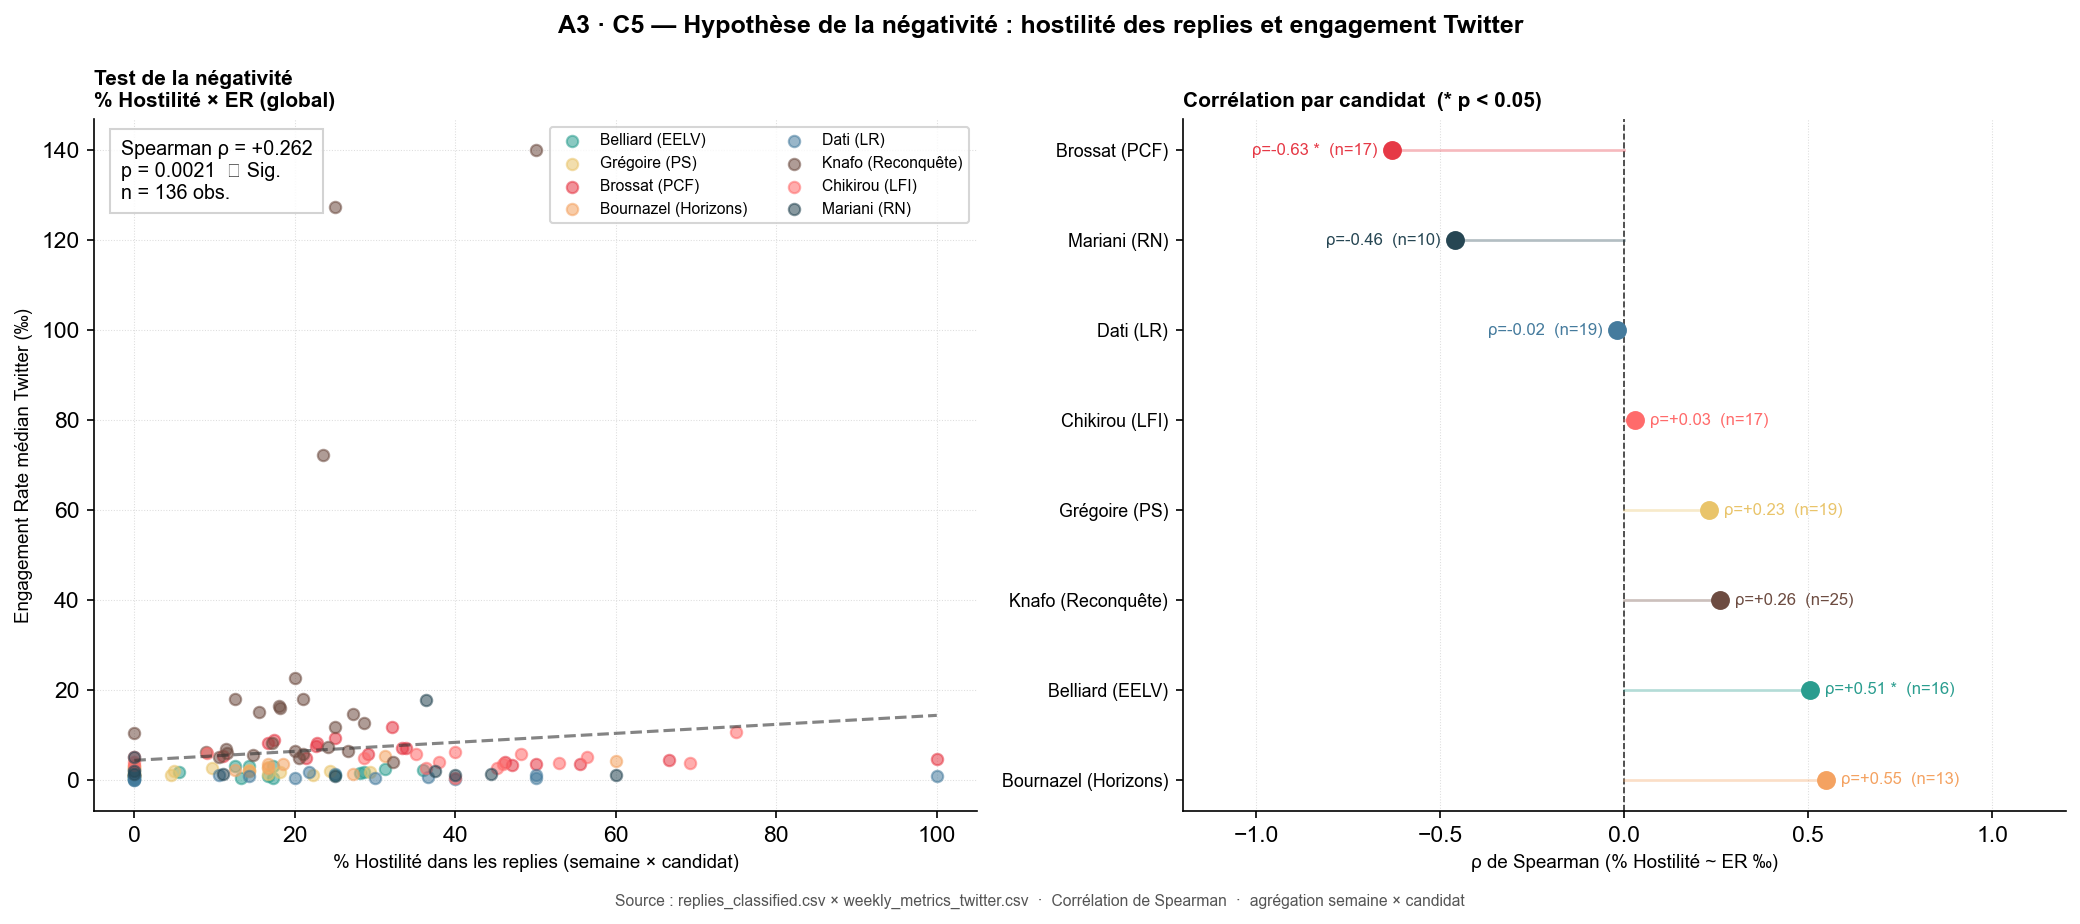

✓ Figure C5 sauvegardée

C5 — TEST DE LA NÉGATIVITÉ
  Spearman global  : ρ = +0.262  p = 0.0021  n = 136
  → Corrélation positive significative : + hostilité = + ER

  Corrélations par candidat :
    Bournazel (Horizons)       ρ=+0.549  p=0.052  
    Belliard (EELV)            ρ=+0.507  p=0.045 *
    Knafo (Reconquête)         ρ=+0.262  p=0.206  
    Grégoire (PS)              ρ=+0.232  p=0.340  
    Chikirou (LFI)             ρ=+0.031  p=0.907  
    Dati (LR)                  ρ=-0.018  p=0.941  
    Mariani (RN)               ρ=-0.460  p=0.181  
    Brossat (PCF)              ρ=-0.630  p=0.007 *


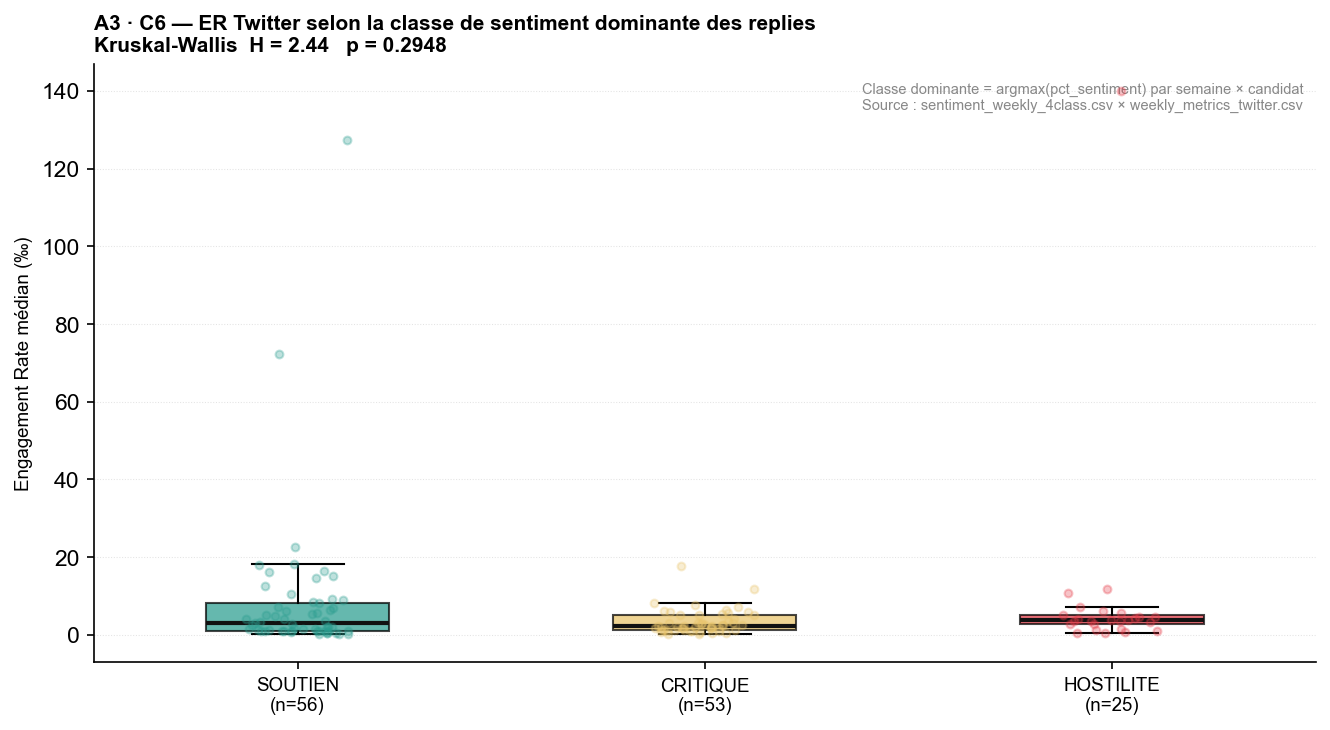

✓ Figure C6 sauvegardée

C6 — ENGAGEMENT × CLASSE DE SENTIMENT DOMINANTE
  Kruskal-Wallis : H = 2.443  p = 0.2948
  Classe           n    Médiane      P25      P75
  --------------------------------------------
  SOUTIEN         56      2.94‰    1.05    8.29
  CRITIQUE        53      2.23‰    1.32    4.99
  HOSTILITE       25      3.77‰    2.66    5.05

  Tests Mann-Whitney (α Bonf. = 0.0167) :
    SOUTIEN vs CRITIQUE      p = 0.3615  ns
    SOUTIEN vs HOSTILITE     p = 0.7243  ns
    CRITIQUE vs HOSTILITE     p = 0.0809  ns

✓ topic_timeline : (591, 4)  | cols : ['week', 'topic_name', 'n_tweets', 'avg_eng']
  Exemple week converti : 2025-W01  (plage : 2025-W01 → 2026-W08)
  Merge topic × sentiment : 29 semaines communes


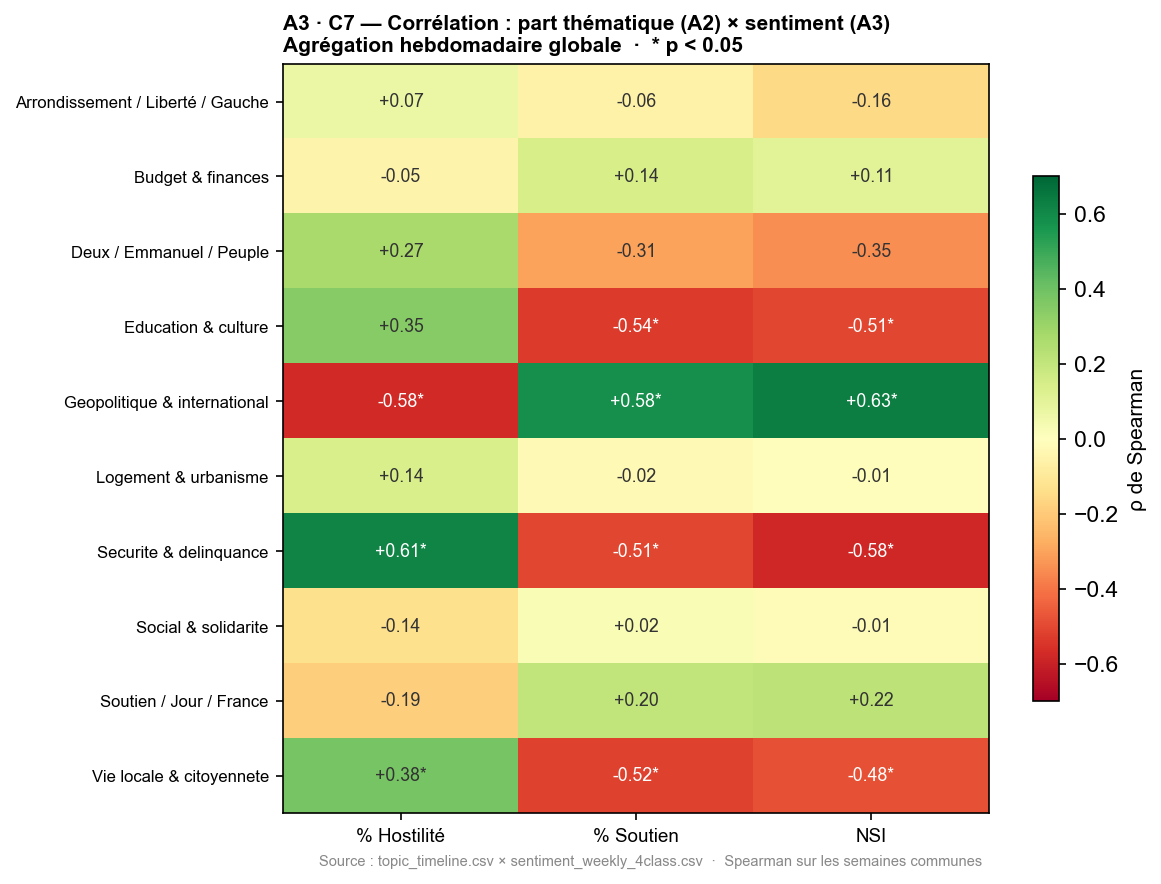

✓ Figure C7 sauvegardée
  11 corrélations significatives / 30 testées
  Top corrélations (|ρ| > 0.4, p < 0.05) :
    Education & culture            ~ pct_soutien      ρ=-0.535  p=0.0028
    Education & culture            ~ net_support      ρ=-0.506  p=0.0051
    Geopolitique & international   ~ pct_hostilite    ρ=-0.578  p=0.0010
    Geopolitique & international   ~ pct_soutien      ρ=+0.582  p=0.0009
    Geopolitique & international   ~ net_support      ρ=+0.632  p=0.0002
    Securite & delinquance         ~ pct_hostilite    ρ=+0.615  p=0.0004
    Securite & delinquance         ~ pct_soutien      ρ=-0.505  p=0.0052
    Securite & delinquance         ~ net_support      ρ=-0.581  p=0.0010
    Vie locale & citoyennete       ~ pct_soutien      ρ=-0.518  p=0.0040
    Vie locale & citoyennete       ~ net_support      ρ=-0.483  p=0.0079


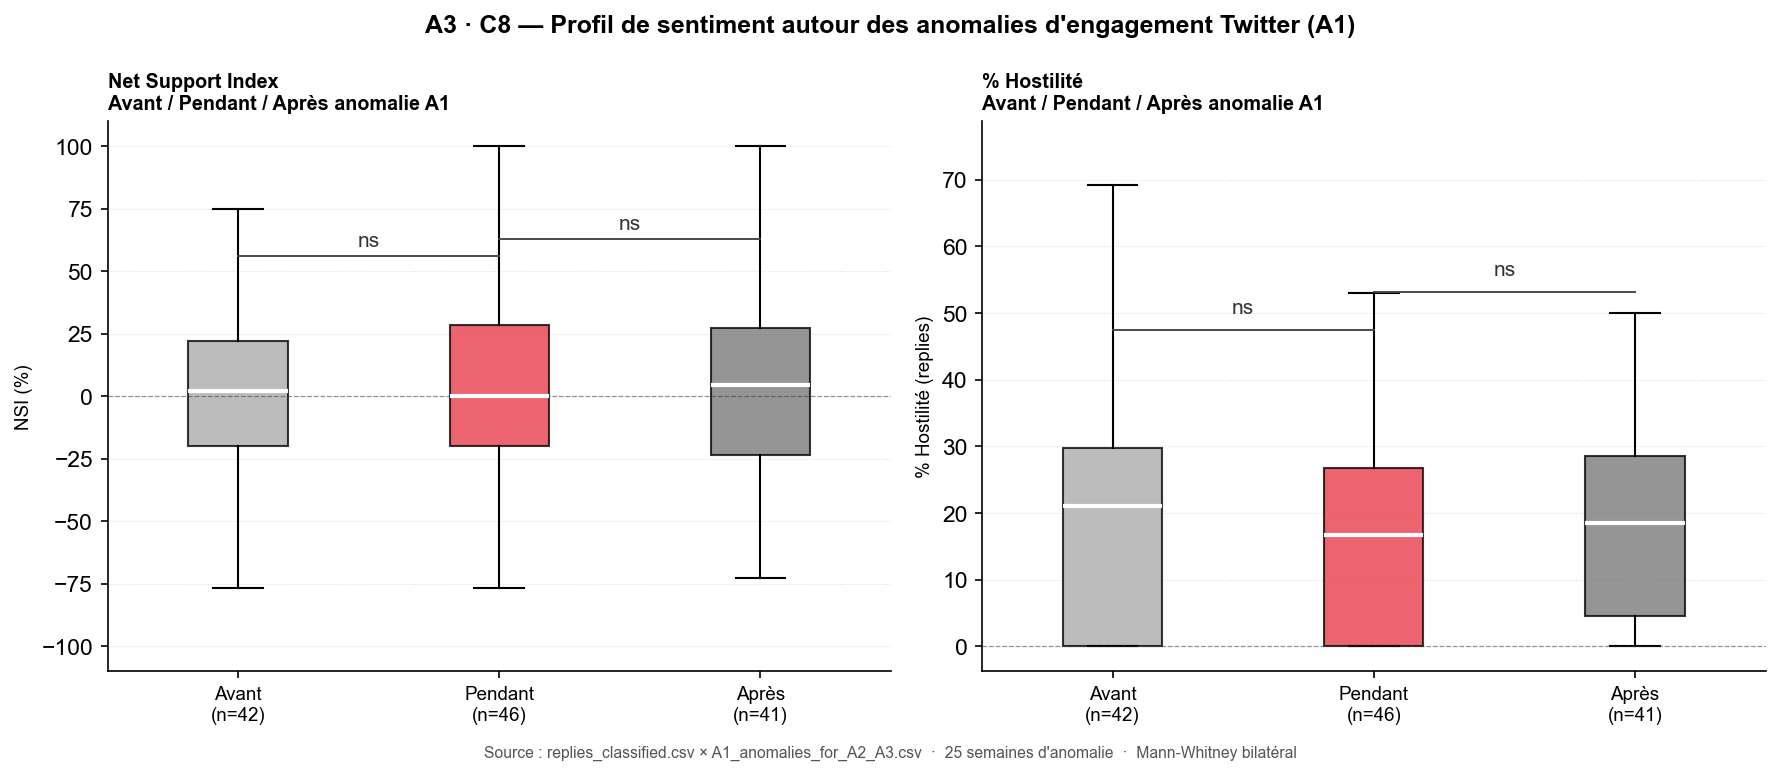

✓ Figure C8 sauvegardée

C8 — SENTIMENT AUTOUR DES ANOMALIES A1
  25 semaines d'anomalie analysées

  NSI (%)         avant=+2.1  pendant=+0.0  après=+4.3
    p avant→pendant = 0.9333  |  p pendant→après = 0.9422
  % Hostilité     avant=+21.0  pendant=+16.7  après=+18.5
    p avant→pendant = 0.4823  |  p pendant→après = 0.6394

✓ Export → outputs/A3_sentiment_vs_anomalies.csv

✓ A3 COMPLET — Exports :
  ✓  A3_C3_nsi_timeline.png
  ✓  A3_C4_bascules.png
  ✓  A3_C5_negativite.png
  ✓  A3_C6_er_by_sentiment.png
  ✓  A3_C7_topic_sentiment.png
  ✓  A3_C8_sentiment_anomalies.png
  ✓  A3_inflection_points.csv
  ✓  A3_sentiment_vs_anomalies.csv
  ✓  A3_nsi_by_candidate.csv
Merge sentiment × Twitter : 136 obs. (semaine × candidat)
  sur 144 sem-sentiments et 427 sem-twitter


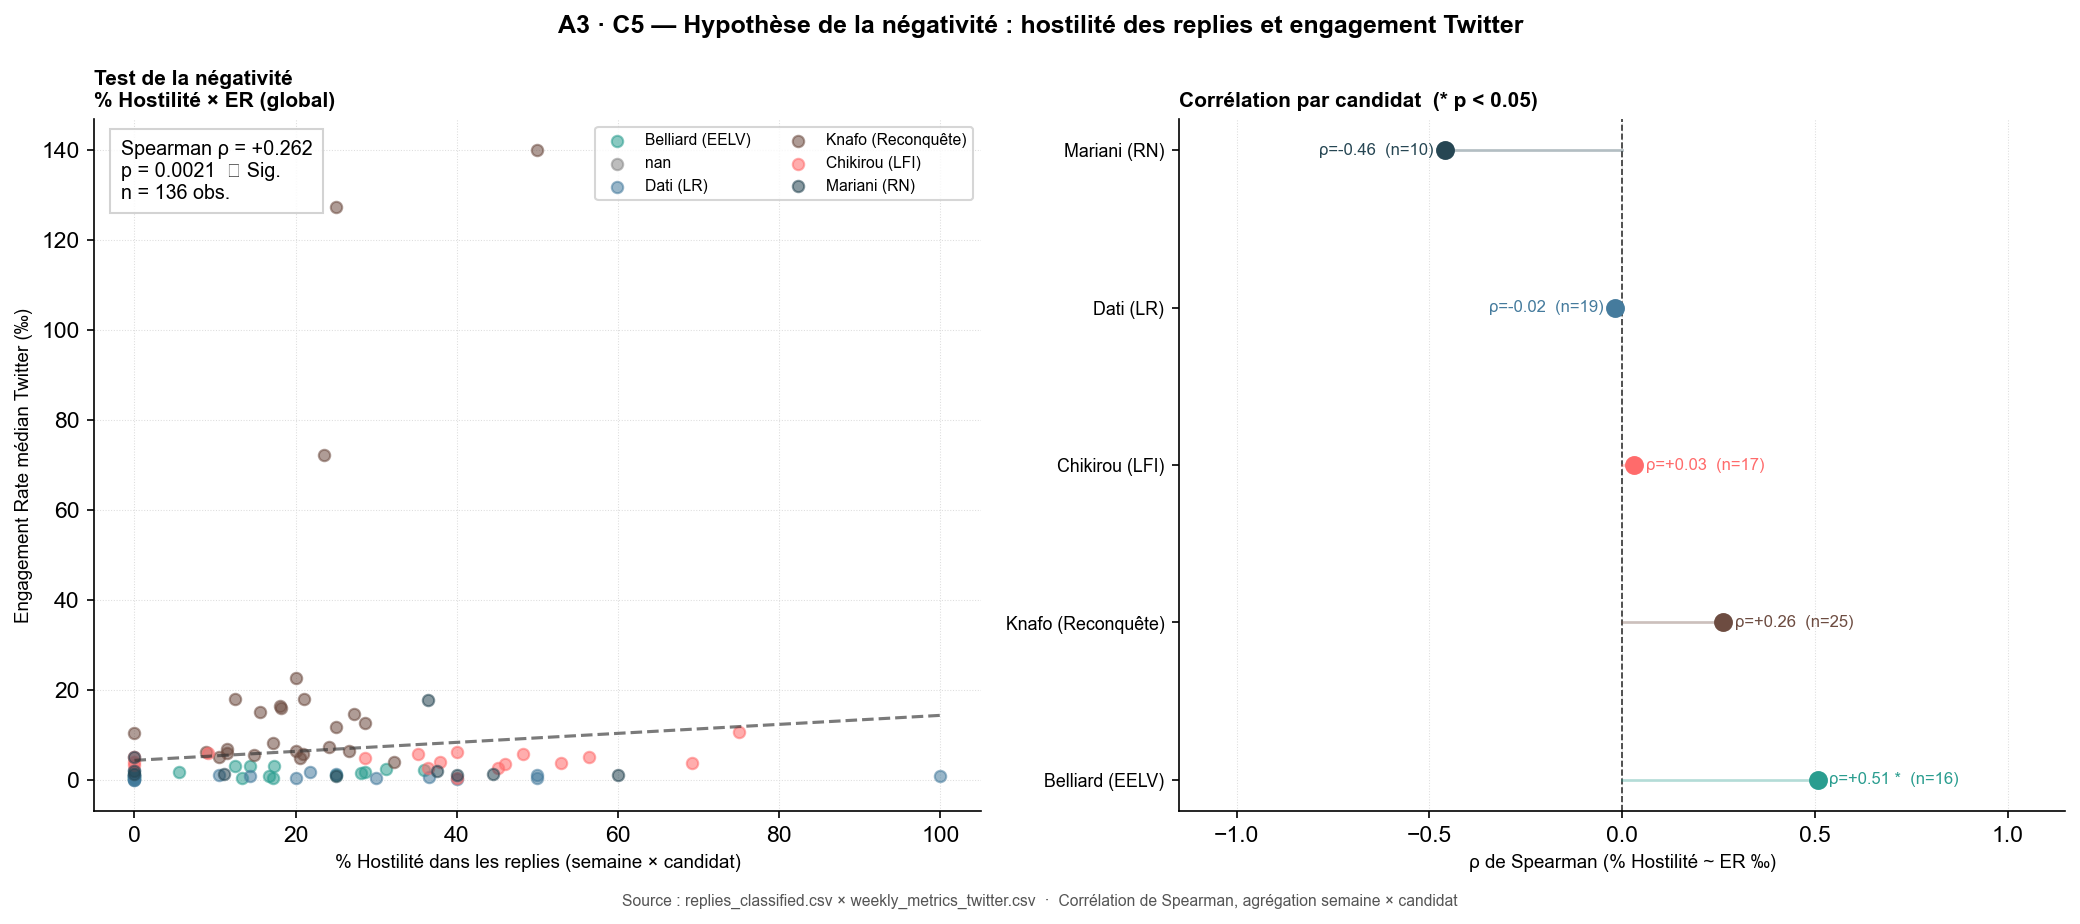

✓ Figure C5 sauvegardée → outputs/A3_C5_negativite.png

C5 — TEST DE LA NÉGATIVITÉ
  Spearman global  : ρ = +0.262  p = 0.0021  n = 136
  → Corrélation positive significative : + hostilité = + ER

  Corrélations par candidat (* p < 0.05) :
    Belliard (EELV)            ρ=+0.507  p=0.045 *
    Knafo (Reconquête)         ρ=+0.262  p=0.206  
    Chikirou (LFI)             ρ=+0.031  p=0.907  
    Dati (LR)                  ρ=-0.018  p=0.941  
    Mariani (RN)               ρ=-0.460  p=0.181  


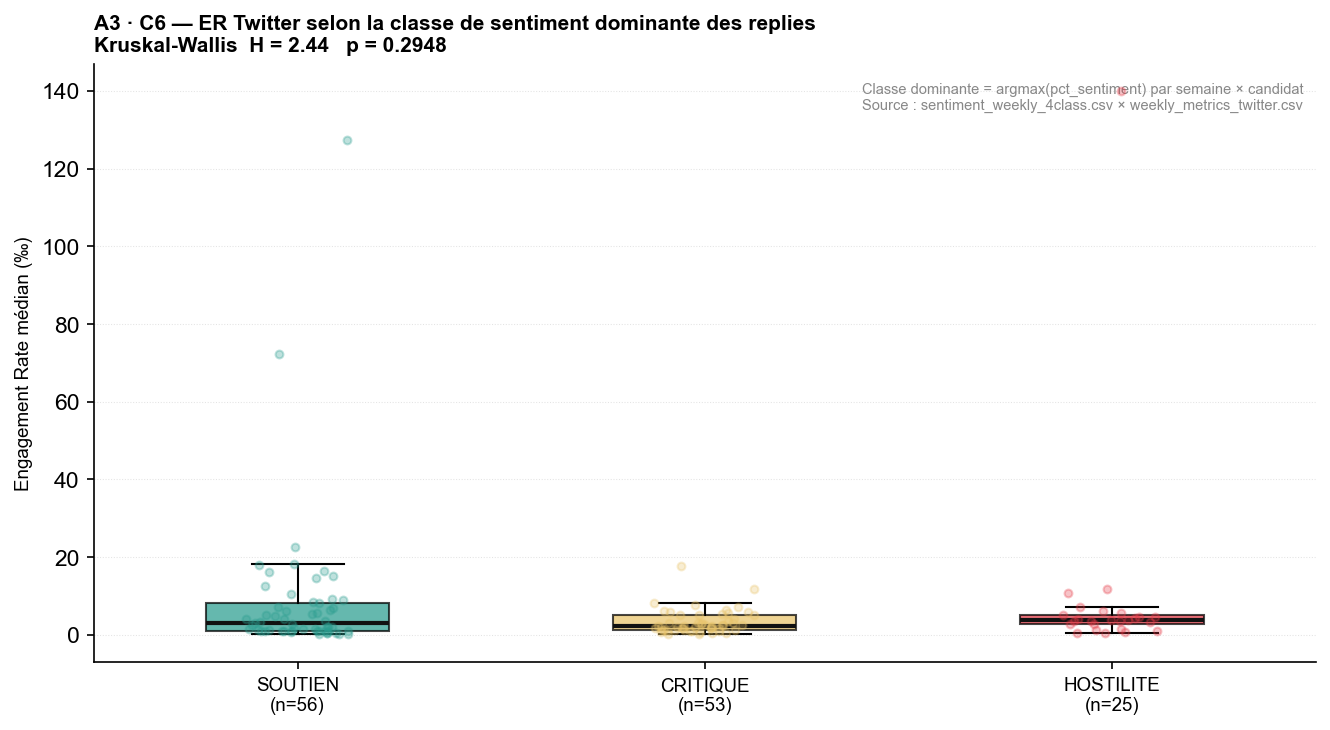

✓ Figure C6 sauvegardée → outputs/A3_C6_er_by_sentiment.png

C6 — ENGAGEMENT × CLASSE DE SENTIMENT DOMINANTE
  Kruskal-Wallis : H = 2.443  p = 0.2948
  α Bonferroni corrigé : 0.0167

  Classe           n    Médiane      P25      P75
  --------------------------------------------
  SOUTIEN         56      2.94‰    1.05    8.29
  CRITIQUE        53      2.23‰    1.32    4.99
  HOSTILITE       25      3.77‰    2.66    5.05

  Tests Mann-Whitney par paire (α Bonf. = 0.0167) :
    SOUTIEN vs CRITIQUE      p = 0.3615  ns
    SOUTIEN vs HOSTILITE     p = 0.7243  ns
    CRITIQUE vs HOSTILITE     p = 0.0809  ns

✓ topic_timeline chargé: (591, 4)  | cols: ['week', 'topic_name', 'n_tweets', 'avg_eng']
⚠ Colonnes topic_id / n_tweets absentes de topic_timeline — C7 ignoré


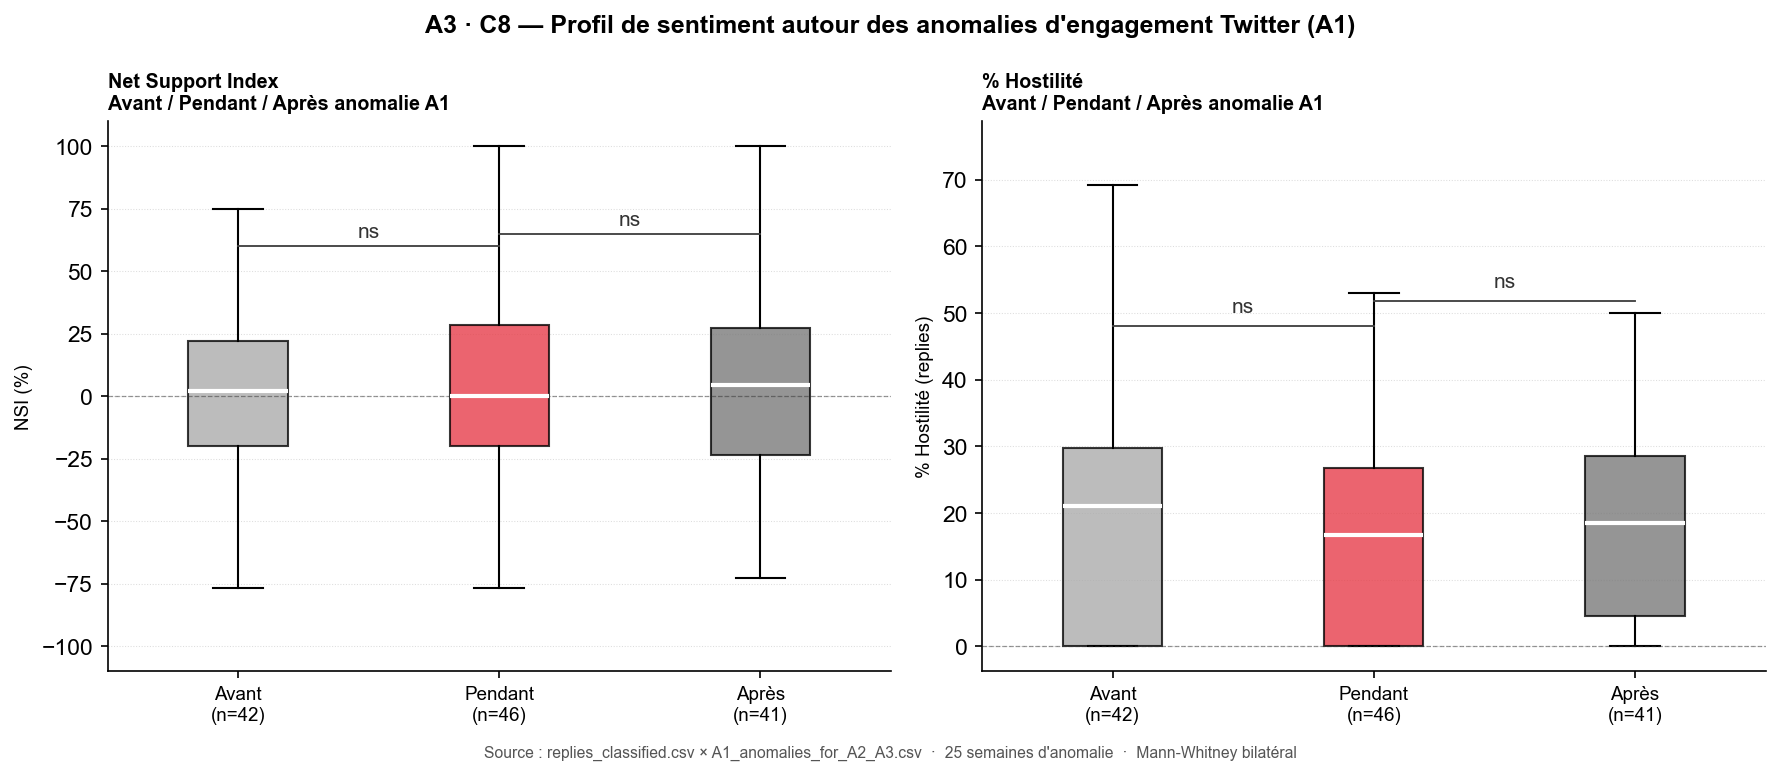

✓ Figure C8 sauvegardée → outputs/A3_C8_sentiment_anomalies.png

C8 — SENTIMENT AUTOUR DES ANOMALIES A1
  25 semaines d'anomalie analysées

  NSI (%)         avant=+2.1  pendant=+0.0  après=+4.3
    Mann-Whitney avant→pendant : p = 0.9333  |  pendant→après : p = 0.9422
  % Hostilité     avant=+21.0  pendant=+16.7  après=+18.5
    Mann-Whitney avant→pendant : p = 0.4823  |  pendant→après : p = 0.6394

✓ Export → outputs/A3_sentiment_vs_anomalies.csv

✓ A3 COMPLET — Exports générés :
  ✓  A3_C3_nsi_timeline.png
  ✓  A3_C4_bascules.png
  ✓  A3_C5_negativite.png
  ✓  A3_C6_er_by_sentiment.png
  ✓  A3_C7_topic_sentiment.png
  ✓  A3_C8_sentiment_anomalies.png
  ✓  A3_inflection_points.csv
  ✓  A3_sentiment_vs_anomalies.csv
  ✓  A3_nsi_by_candidate.csv


In [12]:
# ============================================================
# A3 · Cellule 4 — Test de négativité · Engagement × sentiment · Anomalies
# Fix mapping : même fallback accent-normalisé que cellule 3
# Fix C7 : topic_timeline a 'week' (pas 'year_week') et 'topic_name'
#           → agrégation globale semaine × topic × sentiment
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import unicodedata
from pathlib import Path
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations

BASE    = Path('.')
DATA_A3 = BASE / 'data'
A1_OUT  = Path('..') / 'A1_temporal' / 'outputs'
A2_DATA = Path('..') / 'A2_topics' / 'data'
OUT     = BASE / 'outputs'

ID_TO_KEY = {
    'pierre_yves_brossat':'Brossat', 'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',     'lea_gregoire':'Gregoire',
    'victor_bournazel':'Bournazel',  'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',           'thierry_mariani':'Mariani'
}
SHORT = {
    'Brossat':'Brossat (PCF)',        'Chikirou':'Chikirou (LFI)',
    'Belliard':'Belliard (EELV)',     'Gregoire':'Grégoire (PS)',
    'Bournazel':'Bournazel (Horizons)','Dati':'Dati (LR)',
    'Knafo':'Knafo (Reconquête)',     'Mariani':'Mariani (RN)'
}
COLORS = {
    'Brossat':  '#E63946', 'Chikirou': '#FF6B6B', 'Belliard': '#2A9D8F',
    'Gregoire': '#E9C46A', 'Bournazel':'#F4A261', 'Dati':     '#457B9D',
    'Knafo':    '#6D4C41', 'Mariani':  '#264653'
}
SENT_COLORS = {'SOUTIEN':'#2A9D8F','CRITIQUE':'#E9C46A','IRONIE':'#F4A261','HOSTILITE':'#E63946'}

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s))
                   if unicodedata.category(c) != 'Mn')

# ── Load et mapping robuste ────────────────────────────────────────────────────
sw = pd.read_csv(DATA_A3 / 'sentiment_weekly_4class.csv')
sw['key'] = sw['candidate_id'].map(ID_TO_KEY)
unmapped  = sw['key'].isna()
if unmapped.any():
    sw.loc[unmapped, 'key'] = sw.loc[unmapped, 'candidate'].apply(strip_accents)

tw = pd.read_csv(Path('..') / 'A1_temporal' / 'data' / 'weekly_metrics_twitter.csv')
tw['key'] = tw['candidate_id'].map(ID_TO_KEY)

mer = sw.merge(
    tw[['candidate_id','year_week','er_median','volume','interactions_total']],
    on=['candidate_id','year_week'], how='inner'
).dropna(subset=['er_median','net_support','pct_hostilite'])
mer['er_pct'] = mer['er_median'] * 1000

print(f"Merge sentiment × Twitter : {len(mer)} obs. (candidats couverts : "
      f"{mer['key'].nunique()}/8)")
print(f"  Répartition : " +
      " | ".join(f"{SHORT.get(k,k).split('(')[0].strip()}={len(g)}"
                 for k, g in mer.groupby('key')))

# ═══════════════════════════════════════════════════════════════════════════════
# C5 — Test de la négativité : % Hostilité ~ ER Twitter (Spearman)
# ═══════════════════════════════════════════════════════════════════════════════
rho_g, p_g = stats.spearmanr(mer['pct_hostilite'], mer['er_pct'])

cand_corr = []
for key, grp in mer.groupby('key'):
    if len(grp) < 5:
        continue
    rho, p = stats.spearmanr(grp['pct_hostilite'], grp['er_pct'])
    cand_corr.append({'key':key,'rho':rho,'p_val':p,'n':len(grp)})
cand_corr = pd.DataFrame(cand_corr).sort_values('rho', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for key in mer['key'].unique():
    g = mer[mer['key'] == key]
    ax.scatter(g['pct_hostilite'], g['er_pct'],
               color=COLORS.get(key,'#888888'), alpha=0.55, s=30, zorder=3,
               label=SHORT.get(key, key))
x_ = mer['pct_hostilite'].values
y_ = mer['er_pct'].values
m, b = np.polyfit(x_, y_, 1)
xr = np.linspace(x_.min(), x_.max(), 100)
ax.plot(xr, m*xr + b, '--', lw=1.5, color='#333333', alpha=0.6, zorder=4)

sig_label = '✓ Sig.' if p_g < 0.05 else 'ns'
ax.text(0.03, 0.97,
        f'Spearman ρ = {rho_g:+.3f}\np = {p_g:.4f}  {sig_label}\nn = {len(mer)} obs.',
        transform=ax.transAxes, va='top', fontsize=9.5,
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=5))
ax.legend(fontsize=7.5, loc='upper right', framealpha=0.8, ncol=2)
ax.set_xlabel('% Hostilité dans les replies (semaine × candidat)', fontsize=9)
ax.set_ylabel('Engagement Rate médian Twitter (‰)', fontsize=9)
ax.set_title('Test de la négativité\n% Hostilité × ER (global)', fontsize=10, fontweight='bold', loc='left')
ax.grid(ls=':', lw=0.5, color='#DDDDDD')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

ax2 = axes[1]
ax2.axvline(0, color='#333333', lw=0.8, ls='--')
for i, row in cand_corr.reset_index(drop=True).iterrows():
    color = COLORS.get(row['key'], '#888888')
    sig   = ' *' if row['p_val'] < 0.05 else ''
    ax2.scatter(row['rho'], i, color=color, s=65, zorder=3)
    ax2.plot([row['rho'], 0], [i, i], '-', color=color, lw=1.3, alpha=0.35)
    offset = 0.04 if row['rho'] >= 0 else -0.04
    ha     = 'left' if row['rho'] >= 0 else 'right'
    ax2.text(row['rho'] + offset, i,
             f"ρ={row['rho']:+.2f}{sig}  (n={row['n']})",
             va='center', ha=ha, fontsize=8, color=color)
ax2.set_yticks(range(len(cand_corr)))
ax2.set_yticklabels([SHORT.get(r['key'],r['key']) for _,r in cand_corr.iterrows()], fontsize=8.5)
ax2.set_xlabel('ρ de Spearman (% Hostilité ~ ER ‰)', fontsize=9)
ax2.set_title('Corrélation par candidat  (* p < 0.05)', fontsize=10, fontweight='bold', loc='left')
ax2.set_xlim(-1.2, 1.2)
ax2.grid(axis='x', ls=':', lw=0.5, color='#DDDDDD')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('A3 · C5 — Hypothèse de la négativité : hostilité des replies et engagement Twitter',
             fontsize=12, fontweight='bold')
fig.text(0.5, -0.01,
         'Source : replies_classified.csv × weekly_metrics_twitter.csv  ·  '
         'Corrélation de Spearman  ·  agrégation semaine × candidat',
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A3_C5_negativite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure C5 sauvegardée")

print("\n" + "=" * 62)
print("C5 — TEST DE LA NÉGATIVITÉ")
print("=" * 62)
print(f"  Spearman global  : ρ = {rho_g:+.3f}  p = {p_g:.4f}  n = {len(mer)}")
if p_g < 0.05:
    print(f"  → Corrélation {'positive' if rho_g>0 else 'négative'} significative : "
          f"{'+ hostilité = + ER' if rho_g>0 else '+ hostilité = − ER'}")
else:
    print("  → Pas de corrélation significative globale")
print(f"\n  Corrélations par candidat :")
for _, r in cand_corr.iterrows():
    sig = ' *' if r['p_val'] < 0.05 else '  '
    print(f"    {SHORT.get(r['key'],r['key']):<26} ρ={r['rho']:+.3f}  p={r['p_val']:.3f}{sig}")

# ═══════════════════════════════════════════════════════════════════════════════
# C6 — Engagement × classe de sentiment dominante (Kruskal-Wallis)
# ═══════════════════════════════════════════════════════════════════════════════
dom_cols = ['pct_soutien','pct_critique','pct_hostilite','pct_ironie']
mer['dom_class'] = (mer[dom_cols].idxmax(axis=1)
                    .str.replace('pct_','').str.upper())
SENT_ORDER = ['SOUTIEN','CRITIQUE','IRONIE','HOSTILITE']
groups_er  = {cls: mer[mer['dom_class']==cls]['er_pct'].dropna().values
              for cls in SENT_ORDER if (mer['dom_class']==cls).sum() >= 3}
valid_keys = list(groups_er.keys())

stat_kw, p_kw = kruskal(*[groups_er[k] for k in valid_keys])

fig3, ax3 = plt.subplots(figsize=(9, 5))
bp = ax3.boxplot([groups_er[k] for k in valid_keys],
                 positions=range(len(valid_keys)), patch_artist=True, widths=0.45,
                 medianprops={'color':'#111111','lw':2},
                 flierprops={'marker':'o','ms':3,'alpha':0.3,'markeredgewidth':0})
for patch, key in zip(bp['boxes'], valid_keys):
    patch.set_facecolor(SENT_COLORS.get(key,'#888888'))
    patch.set_alpha(0.72)

rng = np.random.default_rng(42)
for i, key in enumerate(valid_keys):
    jitter = rng.uniform(-0.13, 0.13, len(groups_er[key]))
    ax3.scatter(i + jitter, groups_er[key],
                s=14, alpha=0.30, color=SENT_COLORS.get(key,'#888888'), zorder=4)

alpha_bonf  = 0.05 / max(1, len(list(combinations(valid_keys, 2))))
pair_results = []
y_ceiling    = max(np.percentile(v, 90) for v in groups_er.values()) * 1.3
step         = y_ceiling * 0.08
for pair_i, (k1, k2) in enumerate(combinations(valid_keys, 2)):
    u, p_mw = stats.mannwhitneyu(groups_er[k1], groups_er[k2], alternative='two-sided')
    pair_results.append((k1, k2, p_mw, p_mw < alpha_bonf))
    if p_mw < 0.05:
        i1, i2 = valid_keys.index(k1), valid_keys.index(k2)
        y_bar  = y_ceiling + pair_i * step
        ax3.plot([i1, i2], [y_bar, y_bar], '-', color='#555555', lw=0.9)
        label  = '***' if p_mw<0.001 else ('**' if p_mw<0.01 else '*')
        ax3.text((i1+i2)/2, y_bar+step*0.2, label, ha='center', fontsize=9, color='#333333')

ax3.set_xticks(range(len(valid_keys)))
ax3.set_xticklabels([f'{k}\n(n={len(groups_er[k])})' for k in valid_keys], fontsize=9)
ax3.set_ylabel('Engagement Rate médian (‰)', fontsize=9)
ax3.set_title(f'A3 · C6 — ER Twitter selon la classe de sentiment dominante des replies\n'
              f'Kruskal-Wallis  H = {stat_kw:.2f}   p = {p_kw:.4f}',
              fontsize=10, fontweight='bold', loc='left')
ax3.grid(axis='y', ls=':', lw=0.5, color='#DDDDDD', alpha=0.8)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
ax3.text(0.99, 0.97,
         'Classe dominante = argmax(pct_sentiment) par semaine × candidat\n'
         'Source : sentiment_weekly_4class.csv × weekly_metrics_twitter.csv',
         transform=ax3.transAxes, ha='right', va='top', fontsize=7, color='#888888')
plt.tight_layout()
fig3.savefig(OUT / 'A3_C6_er_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure C6 sauvegardée")

print("\n" + "=" * 55)
print("C6 — ENGAGEMENT × CLASSE DE SENTIMENT DOMINANTE")
print("=" * 55)
print(f"  Kruskal-Wallis : H = {stat_kw:.3f}  p = {p_kw:.4f}")
print(f"  {'Classe':<12}  {'n':>4}  {'Médiane':>9}  {'P25':>7}  {'P75':>7}")
print("  " + "-" * 44)
for cls in valid_keys:
    v = groups_er[cls]
    print(f"  {cls:<12}  {len(v):>4}  {np.median(v):>8.2f}‰  "
          f"{np.percentile(v,25):>6.2f}  {np.percentile(v,75):>6.2f}")
print(f"\n  Tests Mann-Whitney (α Bonf. = {alpha_bonf:.4f}) :")
for k1, k2, p_mw, sig_b in pair_results:
    flag = '** Bonf.' if sig_b else ('* p<0.05' if p_mw<0.05 else 'ns')
    print(f"    {k1} vs {k2:<12}  p = {p_mw:.4f}  {flag}")

# ═══════════════════════════════════════════════════════════════════════════════
# C7 — Croisement A3 × A2 : topic_timeline × sentiment global hebdomadaire
# FIX : topic_timeline.csv a 'week' (pas 'year_week') et 'topic_name'
#       → corrélations Spearman entre % topic et % sentiment (n = semaines communes)
# ═══════════════════════════════════════════════════════════════════════════════
try:
    tl = pd.read_csv(A2_DATA / 'topic_timeline.csv')
    print(f"\n✓ topic_timeline : {tl.shape}  | cols : {tl.columns.tolist()}")

    # FIX : 'week' est une date "2024-12-30" → convertir en ISO week "2025-W01"
    # sentiment_weekly a 'year_week' en format "2025-W06" → même convention
    week_col = 'week' if 'week' in tl.columns else 'year_week'
    if week_col == 'week':
        tl['year_week'] = pd.to_datetime(tl['week']).dt.strftime('%G-W%V')
        tl = tl.drop(columns=['week'])
    print(f"  Exemple week converti : {tl['year_week'].iloc[0]}  "
          f"(plage : {tl['year_week'].min()} → {tl['year_week'].max()})")

    tl_pivot = (tl.pivot_table(index='year_week', columns='topic_name',
                                values='n_tweets', aggfunc='sum', fill_value=0))
    tl_pivot = tl_pivot.div(tl_pivot.sum(axis=1), axis=0)   # → % par semaine
    tl_pivot.columns.name = None
    tl_pivot = tl_pivot.reset_index()

    # Sentiment global par semaine (moyenne sur les 8 candidats)
    sw_global = (sw.groupby('year_week')
                   .agg(net_support=('net_support','mean'),
                        pct_hostilite=('pct_hostilite','mean'),
                        pct_soutien=('pct_soutien','mean'),
                        n_cand=('key','nunique'))
                   .reset_index())

    cross7 = tl_pivot.merge(sw_global, on='year_week', how='inner')
    print(f"  Merge topic × sentiment : {len(cross7)} semaines communes")

    topic_cols   = [c for c in cross7.columns if c not in
                    ['year_week','net_support','pct_hostilite','pct_soutien','n_cand']]
    sent_targets = ['pct_hostilite','pct_soutien','net_support']

    rho_mat = pd.DataFrame(index=topic_cols, columns=sent_targets, dtype=float)
    p_mat   = pd.DataFrame(index=topic_cols, columns=sent_targets, dtype=float)
    for tc in topic_cols:
        for sc in sent_targets:
            valid = cross7[[tc, sc]].dropna()
            if len(valid) >= 6:
                rho, p = stats.spearmanr(valid[tc], valid[sc])
                rho_mat.loc[tc, sc] = rho
                p_mat.loc[tc, sc]   = p
            else:
                rho_mat.loc[tc, sc] = np.nan
                p_mat.loc[tc, sc]   = np.nan

    # Heatmap
    fig4, ax4 = plt.subplots(figsize=(8, max(5, len(topic_cols) * 0.6)))
    data_plot = rho_mat.astype(float)
    im = ax4.imshow(data_plot.values, cmap='RdYlGn', vmin=-0.7, vmax=0.7, aspect='auto')

    ax4.set_xticks(range(len(sent_targets)))
    ax4.set_xticklabels(['% Hostilité', '% Soutien', 'NSI'], fontsize=9)
    ax4.set_yticks(range(len(topic_cols)))
    ax4.set_yticklabels(topic_cols, fontsize=8)

    for i, tc in enumerate(topic_cols):
        for j, sc in enumerate(sent_targets):
            rv = data_plot.loc[tc, sc]
            pv = p_mat.loc[tc, sc]
            if pd.notna(rv):
                sig = '*' if (pd.notna(pv) and pv < 0.05) else ''
                ax4.text(j, i, f'{rv:+.2f}{sig}',
                         ha='center', va='center', fontsize=8.5,
                         color='white' if abs(rv) > 0.4 else '#333333')

    plt.colorbar(im, ax=ax4, shrink=0.7, label='ρ de Spearman')
    ax4.set_title('A3 · C7 — Corrélation : part thématique (A2) × sentiment (A3)\n'
                  'Agrégation hebdomadaire globale  ·  * p < 0.05',
                  fontsize=10, fontweight='bold', loc='left')
    ax4.text(0.99, -0.07,
             'Source : topic_timeline.csv × sentiment_weekly_4class.csv  '
             '·  Spearman sur les semaines communes',
             transform=ax4.transAxes, ha='right', fontsize=7, color='#888888')
    plt.tight_layout()
    fig4.savefig(OUT / 'A3_C7_topic_sentiment.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure C7 sauvegardée")

    sig_n = int((p_mat.astype(float) < 0.05).sum().sum())
    print(f"  {sig_n} corrélations significatives / {len(topic_cols)*len(sent_targets)} testées")
    print("  Top corrélations (|ρ| > 0.4, p < 0.05) :")
    for tc in topic_cols:
        for sc in sent_targets:
            rv = rho_mat.loc[tc, sc]
            pv = p_mat.loc[tc, sc]
            if pd.notna(rv) and abs(rv) > 0.4 and pd.notna(pv) and pv < 0.05:
                print(f"    {tc:<30} ~ {sc:<16} ρ={rv:+.3f}  p={pv:.4f}")

except FileNotFoundError:
    print("⚠ topic_timeline.csv non trouvé dans A2_topics/data — C7 ignoré")

# ═══════════════════════════════════════════════════════════════════════════════
# C8 — Profil de sentiment autour des anomalies A1
# ═══════════════════════════════════════════════════════════════════════════════
try:
    anom_df    = pd.read_csv(A1_OUT / 'A1_anomalies_for_A2_A3.csv')
    anom_weeks = sorted(set(anom_df['year_week'].tolist()))
    all_weeks  = sorted(sw['year_week'].unique())
    week_idx   = {w: i for i, w in enumerate(all_weeks)}

    before_nsi,  during_nsi,  after_nsi  = [], [], []
    before_host, during_host, after_host = [], [], []

    for aw in anom_weeks:
        if aw not in week_idx: continue
        idx   = week_idx[aw]
        w_bef = all_weeks[idx-1] if idx > 0 else None
        w_aft = all_weeks[idx+1] if idx < len(all_weeks)-1 else None

        d_dur = sw[sw['year_week'] == aw]
        d_bef = sw[sw['year_week'] == w_bef] if w_bef else pd.DataFrame()
        d_aft = sw[sw['year_week'] == w_aft] if w_aft else pd.DataFrame()

        if not d_dur.empty:
            during_nsi.extend(d_dur['net_support'].tolist())
            during_host.extend(d_dur['pct_hostilite'].tolist())
        if not d_bef.empty:
            before_nsi.extend(d_bef['net_support'].tolist())
            before_host.extend(d_bef['pct_hostilite'].tolist())
        if not d_aft.empty:
            after_nsi.extend(d_aft['net_support'].tolist())
            after_host.extend(d_aft['pct_hostilite'].tolist())

    def mw(a, b):
        return stats.mannwhitneyu(a, b, alternative='two-sided')[1] if (len(a)>=3 and len(b)>=3) else np.nan

    p_bd_nsi  = mw(before_nsi,  during_nsi)
    p_da_nsi  = mw(during_nsi,  after_nsi)
    p_bd_host = mw(before_host, during_host)
    p_da_host = mw(during_host, after_host)

    fig5, axes5 = plt.subplots(1, 2, figsize=(12, 5))
    colors_p = ['#AAAAAA','#E63946','#777777']

    for ax_i, (data_list, title, yl, p1, p2) in enumerate([
        ([before_nsi,  during_nsi,  after_nsi],  'Net Support Index',  'NSI (%)',               p_bd_nsi,  p_da_nsi),
        ([before_host, during_host, after_host],  '% Hostilité',        '% Hostilité (replies)', p_bd_host, p_da_host)
    ]):
        ax5     = axes5[ax_i]
        labels5 = [f'Avant\n(n={len(data_list[0])})',
                   f'Pendant\n(n={len(data_list[1])})',
                   f'Après\n(n={len(data_list[2])})']
        bp5 = ax5.boxplot(data_list, patch_artist=True, widths=0.38,
                          medianprops={'color':'white','lw':2},
                          flierprops={'marker':'o','ms':3,'alpha':0.3,'markeredgewidth':0})
        for patch, color in zip(bp5['boxes'], colors_p):
            patch.set_facecolor(color); patch.set_alpha(0.78)

        flat  = [v for d in data_list for v in d]
        y_top = np.percentile(flat, 88) * 1.25 if flat else 1
        for pair_i, (pos1, pos2, pv) in enumerate([(1,2,p1),(2,3,p2)]):
            if pd.notna(pv):
                y_bar = y_top + pair_i * abs(y_top) * 0.12
                ax5.plot([pos1,pos2],[y_bar,y_bar],'-',color='#444444',lw=0.9)
                flag = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
                ax5.text((pos1+pos2)/2, y_bar+abs(y_top)*0.04, flag,
                         ha='center', va='bottom', fontsize=10, color='#333333')

        ax5.axhline(0, color='#333333', lw=0.6, ls='--', alpha=0.5)
        ax5.set_xticklabels(labels5, fontsize=9)
        ax5.set_ylabel(yl, fontsize=9)
        ax5.set_title(f'{title}\nAvant / Pendant / Après anomalie A1',
                      fontsize=9.5, fontweight='bold', loc='left')
        ax5.grid(axis='y', ls=':', lw=0.5, color='#DDDDDD')
        for sp in ['top','right']: ax5.spines[sp].set_visible(False)

    fig5.suptitle('A3 · C8 — Profil de sentiment autour des anomalies d\'engagement Twitter (A1)',
                  fontsize=12, fontweight='bold')
    fig5.text(0.5, -0.01,
              f'Source : replies_classified.csv × A1_anomalies_for_A2_A3.csv  ·  '
              f'{len(anom_weeks)} semaines d\'anomalie  ·  Mann-Whitney bilatéral',
              ha='center', fontsize=7.5, color='#555555')
    plt.tight_layout()
    fig5.savefig(OUT / 'A3_C8_sentiment_anomalies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure C8 sauvegardée")

    print("\n" + "=" * 60)
    print("C8 — SENTIMENT AUTOUR DES ANOMALIES A1")
    print("=" * 60)
    print(f"  {len(anom_weeks)} semaines d'anomalie analysées\n")
    for label, bef, dur, aft, p1, p2 in [
        ('NSI (%)',      before_nsi,  during_nsi,  after_nsi,  p_bd_nsi,  p_da_nsi),
        ('% Hostilité', before_host, during_host, after_host, p_bd_host, p_da_host)
    ]:
        mb = f'{np.median(bef):+.1f}' if bef else 'n/a'
        md = f'{np.median(dur):+.1f}' if dur else 'n/a'
        ma = f'{np.median(aft):+.1f}' if aft else 'n/a'
        print(f"  {label:<14}  avant={mb}  pendant={md}  après={ma}")
        print(f"    p avant→pendant = {p1:.4f}  |  p pendant→après = {p2:.4f}")

    pd.DataFrame({
        'periode':     ['avant','pendant','après'],
        'n':           [len(before_nsi), len(during_nsi), len(after_nsi)],
        'med_nsi':     [np.median(before_nsi)  if before_nsi  else np.nan,
                        np.median(during_nsi)   if during_nsi  else np.nan,
                        np.median(after_nsi)    if after_nsi   else np.nan],
        'med_hostilite':[np.median(before_host) if before_host else np.nan,
                         np.median(during_host)  if during_host else np.nan,
                         np.median(after_host)   if after_host  else np.nan],
        'p_mw_nsi_bd':  [np.nan, p_bd_nsi,  np.nan],
        'p_mw_nsi_da':  [np.nan, np.nan,     p_da_nsi],
        'p_mw_host_bd': [np.nan, p_bd_host,  np.nan],
        'p_mw_host_da': [np.nan, np.nan,     p_da_host]
    }).to_csv(OUT / 'A3_sentiment_vs_anomalies.csv', index=False)
    print(f"\n✓ Export → outputs/A3_sentiment_vs_anomalies.csv")

except FileNotFoundError:
    print("⚠ A1_anomalies_for_A2_A3.csv non trouvé — C8 ignoré")

# ── Récapitulatif final ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("✓ A3 COMPLET — Exports :")
for f in ['A3_C3_nsi_timeline.png','A3_C4_bascules.png','A3_C5_negativite.png',
          'A3_C6_er_by_sentiment.png','A3_C7_topic_sentiment.png',
          'A3_C8_sentiment_anomalies.png','A3_inflection_points.csv',
          'A3_sentiment_vs_anomalies.csv','A3_nsi_by_candidate.csv']:
    status = '✓' if (OUT/f).exists() else '⚠ manquant'
    print(f"  {status}  {f}")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from scipy.stats import kruskal
from itertools import combinations

BASE    = Path('.')
DATA_A3 = BASE / 'data'
A1_OUT  = Path('..') / 'A1_temporal' / 'outputs'
A2_DATA = Path('..') / 'A2_topics' / 'data'
OUT     = BASE / 'outputs'

ID_TO_KEY = {
    'pierre_yves_brossat':'Brossat', 'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',     'lea_gregoire':'Gregoire',
    'victor_bournazel':'Bournazel',  'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',           'thierry_mariani':'Mariani'
}
SHORT = {
    'Brossat':'Brossat (PCF)',   'Chikirou':'Chikirou (LFI)',
    'Belliard':'Belliard (EELV)','Gregoire':'Grégoire (PS)',
    'Bournazel':'Bournazel (Horizons)', 'Dati':'Dati (LR)',
    'Knafo':'Knafo (Reconquête)', 'Mariani':'Mariani (RN)'
}
COLORS = {
    'Brossat':  '#E63946', 'Chikirou': '#FF6B6B', 'Belliard': '#2A9D8F',
    'Gregoire': '#E9C46A', 'Bournazel':'#F4A261', 'Dati':     '#457B9D',
    'Knafo':    '#6D4C41', 'Mariani':  '#264653'
}
SENT_COLORS = {'SOUTIEN':'#2A9D8F','CRITIQUE':'#E9C46A','IRONIE':'#F4A261','HOSTILITE':'#E63946'}

# ── Load données ─────────────────────────────────────────────────────────────
sw  = pd.read_csv(DATA_A3 / 'sentiment_weekly_4class.csv')
sw['key'] = sw['candidate_id'].map(ID_TO_KEY)

tw  = pd.read_csv(Path('..') / 'A1_temporal' / 'data' / 'weekly_metrics_twitter.csv')
tw['key'] = tw['candidate_id'].map(ID_TO_KEY)

# Merge sentiment × Twitter (inner join sur candidate_id × year_week)
mer = sw.merge(
    tw[['candidate_id', 'year_week', 'er_median', 'volume', 'interactions_total']],
    on=['candidate_id', 'year_week'], how='inner'
).dropna(subset=['er_median', 'net_support', 'pct_hostilite'])
mer['er_pct'] = mer['er_median'] * 1000   # → ‰

print(f"Merge sentiment × Twitter : {len(mer)} obs. (semaine × candidat)")
print(f"  sur {len(sw)} sem-sentiments et {len(tw)} sem-twitter")

# ═══════════════════════════════════════════════════════════════════════════════
# C5 — Test de la négativité : % Hostilité ~ ER Twitter
# H0 : pas de corrélation entre la semaine de forte hostilité et l'engagement
# ═══════════════════════════════════════════════════════════════════════════════
rho_g, p_g = stats.spearmanr(mer['pct_hostilite'], mer['er_pct'])

cand_corr = []
for key, grp in mer.groupby('key'):
    if len(grp) < 5:
        continue
    rho, p = stats.spearmanr(grp['pct_hostilite'], grp['er_pct'])
    cand_corr.append({'key': key, 'rho': rho, 'p_val': p, 'n': len(grp)})
cand_corr = pd.DataFrame(cand_corr).sort_values('rho', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter global
ax = axes[0]
for key in mer['key'].unique():
    g = mer[mer['key'] == key]
    ax.scatter(g['pct_hostilite'], g['er_pct'],
               color=COLORS.get(key, '#888888'), alpha=0.55, s=30, zorder=3,
               label=SHORT.get(key, key))
x_ = mer['pct_hostilite'].values
y_ = mer['er_pct'].values
m, b = np.polyfit(x_, y_, 1)
xr = np.linspace(x_.min(), x_.max(), 100)
ax.plot(xr, m * xr + b, '--', lw=1.5, color='#333333', alpha=0.65, zorder=4)

sig_label = '✓ Sig.' if p_g < 0.05 else 'ns'
ax.text(0.03, 0.97,
        f'Spearman ρ = {rho_g:+.3f}\np = {p_g:.4f}  {sig_label}\nn = {len(mer)} obs.',
        transform=ax.transAxes, va='top', fontsize=9.5,
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=5))
ax.legend(fontsize=7.5, loc='upper right', framealpha=0.8, ncol=2)
ax.set_xlabel('% Hostilité dans les replies (semaine × candidat)', fontsize=9)
ax.set_ylabel('Engagement Rate médian Twitter (‰)', fontsize=9)
ax.set_title('Test de la négativité\n% Hostilité × ER (global)', fontsize=10, fontweight='bold', loc='left')
ax.grid(ls=':', lw=0.5, color='#DDDDDD')
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

# Dot plot ρ par candidat
ax2 = axes[1]
ax2.axvline(0, color='#333333', lw=0.8, ls='--')
for i, row in cand_corr.reset_index(drop=True).iterrows():
    color = COLORS.get(row['key'], '#888888')
    sig   = ' *' if row['p_val'] < 0.05 else ''
    ax2.scatter(row['rho'], i, color=color, s=65, zorder=3)
    ax2.plot([row['rho'], 0], [i, i], '-', color=color, lw=1.3, alpha=0.35)
    offset = 0.03 if row['rho'] >= 0 else -0.03
    ha     = 'left' if row['rho'] >= 0 else 'right'
    ax2.text(row['rho'] + offset, i,
             f"ρ={row['rho']:+.2f}{sig}  (n={row['n']})",
             va='center', ha=ha, fontsize=8, color=color)

ax2.set_yticks(range(len(cand_corr)))
ax2.set_yticklabels([SHORT.get(r['key'], r['key']) for _, r in cand_corr.iterrows()], fontsize=8.5)
ax2.set_xlabel('ρ de Spearman (% Hostilité ~ ER ‰)', fontsize=9)
ax2.set_title('Corrélation par candidat  (* p < 0.05)', fontsize=10, fontweight='bold', loc='left')
ax2.set_xlim(-1.15, 1.15)
ax2.grid(axis='x', ls=':', lw=0.5, color='#DDDDDD')
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)

fig.suptitle('A3 · C5 — Hypothèse de la négativité : hostilité des replies et engagement Twitter',
             fontsize=12, fontweight='bold')
fig.text(0.5, -0.01,
         'Source : replies_classified.csv × weekly_metrics_twitter.csv  ·  '
         'Corrélation de Spearman, agrégation semaine × candidat',
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A3_C5_negativite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure C5 sauvegardée → outputs/A3_C5_negativite.png")

print("\n" + "=" * 62)
print("C5 — TEST DE LA NÉGATIVITÉ")
print("=" * 62)
print(f"  Spearman global  : ρ = {rho_g:+.3f}  p = {p_g:.4f}  n = {len(mer)}")
interp = ("→ Corrélation positive significative : + hostilité = + ER"
          if (p_g < 0.05 and rho_g > 0) else
          "→ Corrélation négative significative : + hostilité = − ER"
          if (p_g < 0.05 and rho_g < 0) else
          "→ Pas de corrélation significative globale (H0 non rejetée)")
print(f"  {interp}")
print(f"\n  Corrélations par candidat (* p < 0.05) :")
for _, r in cand_corr.iterrows():
    sig = ' *' if r['p_val'] < 0.05 else '  '
    print(f"    {SHORT.get(r['key'], r['key']):<26} ρ={r['rho']:+.3f}  p={r['p_val']:.3f}{sig}")

# ═══════════════════════════════════════════════════════════════════════════════
# C6 — Engagement × classe de sentiment dominante (Kruskal-Wallis)
# ═══════════════════════════════════════════════════════════════════════════════
dom_cols = ['pct_soutien', 'pct_critique', 'pct_hostilite', 'pct_ironie']
mer['dom_class'] = (mer[dom_cols]
                    .idxmax(axis=1)
                    .str.replace('pct_', '')
                    .str.upper())

SENT_ORDER = ['SOUTIEN', 'CRITIQUE', 'IRONIE', 'HOSTILITE']
groups_er  = {
    cls: mer[mer['dom_class'] == cls]['er_pct'].dropna().values
    for cls in SENT_ORDER
    if (mer['dom_class'] == cls).sum() >= 3
}
valid_keys = list(groups_er.keys())

stat_kw, p_kw = kruskal(*[groups_er[k] for k in valid_keys])

fig3, ax3 = plt.subplots(figsize=(9, 5))
bp = ax3.boxplot(
    [groups_er[k] for k in valid_keys],
    positions=range(len(valid_keys)),
    patch_artist=True, widths=0.45,
    medianprops={'color': '#111111', 'lw': 2},
    flierprops={'marker': 'o', 'ms': 3, 'alpha': 0.3, 'markeredgewidth': 0}
)
for patch, key in zip(bp['boxes'], valid_keys):
    patch.set_facecolor(SENT_COLORS.get(key, '#888888'))
    patch.set_alpha(0.72)

rng = np.random.default_rng(42)
for i, key in enumerate(valid_keys):
    jitter = rng.uniform(-0.13, 0.13, len(groups_er[key]))
    ax3.scatter(i + jitter, groups_er[key],
                s=14, alpha=0.30, color=SENT_COLORS.get(key, '#888888'), zorder=4)

# Barres de signification Mann-Whitney par paire
alpha_bonf  = 0.05 / len(list(combinations(valid_keys, 2)))
pair_results = []
y_ceiling    = max(v.max() for v in groups_er.values()) * 1.05
step         = y_ceiling * 0.06

for pair_i, (k1, k2) in enumerate(combinations(valid_keys, 2)):
    u, p_mw = stats.mannwhitneyu(groups_er[k1], groups_er[k2], alternative='two-sided')
    pair_results.append((k1, k2, p_mw, p_mw < alpha_bonf))
    if p_mw < 0.05:
        i1, i2  = valid_keys.index(k1), valid_keys.index(k2)
        y_bar   = y_ceiling + pair_i * step
        ax3.plot([i1, i2], [y_bar, y_bar], '-', color='#555555', lw=0.9)
        label   = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else '*')
        ax3.text((i1 + i2) / 2, y_bar + step * 0.2, label,
                 ha='center', va='bottom', fontsize=9, color='#333333')

ax3.set_xticks(range(len(valid_keys)))
ax3.set_xticklabels(
    [f'{k}\n(n={len(groups_er[k])})' for k in valid_keys], fontsize=9
)
ax3.set_ylabel('Engagement Rate médian (‰)', fontsize=9)
ax3.set_title(
    f'A3 · C6 — ER Twitter selon la classe de sentiment dominante des replies\n'
    f'Kruskal-Wallis  H = {stat_kw:.2f}   p = {p_kw:.4f}',
    fontsize=10, fontweight='bold', loc='left'
)
ax3.grid(axis='y', ls=':', lw=0.5, color='#DDDDDD', alpha=0.8)
for sp in ['top', 'right']:
    ax3.spines[sp].set_visible(False)
ax3.text(0.99, 0.97,
         'Classe dominante = argmax(pct_sentiment) par semaine × candidat\n'
         'Source : sentiment_weekly_4class.csv × weekly_metrics_twitter.csv',
         transform=ax3.transAxes, ha='right', va='top', fontsize=7, color='#888888')

plt.tight_layout()
fig3.savefig(OUT / 'A3_C6_er_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure C6 sauvegardée → outputs/A3_C6_er_by_sentiment.png")

print("\n" + "=" * 55)
print("C6 — ENGAGEMENT × CLASSE DE SENTIMENT DOMINANTE")
print("=" * 55)
print(f"  Kruskal-Wallis : H = {stat_kw:.3f}  p = {p_kw:.4f}")
print(f"  α Bonferroni corrigé : {alpha_bonf:.4f}\n")
print(f"  {'Classe':<12}  {'n':>4}  {'Médiane':>9}  {'P25':>7}  {'P75':>7}")
print("  " + "-" * 44)
for cls in valid_keys:
    v = groups_er[cls]
    print(f"  {cls:<12}  {len(v):>4}  {np.median(v):>8.2f}‰  "
          f"{np.percentile(v, 25):>6.2f}  {np.percentile(v, 75):>6.2f}")
print(f"\n  Tests Mann-Whitney par paire (α Bonf. = {alpha_bonf:.4f}) :")
for k1, k2, p_mw, sig_b in pair_results:
    flag = '** Bonf.' if sig_b else ('* p<0.05' if p_mw < 0.05 else 'ns')
    print(f"    {k1} vs {k2:<12}  p = {p_mw:.4f}  {flag}")

# ═══════════════════════════════════════════════════════════════════════════════
# C7 — Croisement A3 × A2 : sentiment ~ mix thématique
# Méthode : pour chaque semaine × candidat, Spearman entre pct_topic et pct_sentiment
# ═══════════════════════════════════════════════════════════════════════════════
try:
    tl = pd.read_csv(A2_DATA / 'topic_timeline.csv')
    print("\n✓ topic_timeline chargé:", tl.shape, " | cols:", tl.columns.tolist()[:8])

    # Pivoter : semaine × topic → pivot large
    if 'topic_id' in tl.columns and 'n_tweets' in tl.columns:
        tl_pivot = (tl.groupby(['candidate_id', 'year_week', 'topic_id'])['n_tweets']
                      .sum().unstack(fill_value=0))
        tl_pivot.columns = [f'T{c}' for c in tl_pivot.columns]
        tl_pivot = tl_pivot.div(tl_pivot.sum(axis=1), axis=0)   # normalisation → %
        tl_pivot = tl_pivot.reset_index()

        sw_merge = sw[['candidate_id', 'year_week',
                        'pct_hostilite', 'pct_soutien', 'net_support']].copy()
        cross = tl_pivot.merge(sw_merge, on=['candidate_id', 'year_week'], how='inner')
        print(f"  Merge topic × sentiment : {len(cross)} obs.")

        topic_cols = [c for c in cross.columns if c.startswith('T')]
        sent_targets = ['pct_hostilite', 'pct_soutien', 'net_support']

        rho_matrix = pd.DataFrame(index=topic_cols, columns=sent_targets, dtype=float)
        p_matrix   = pd.DataFrame(index=topic_cols, columns=sent_targets, dtype=float)
        for tc in topic_cols:
            for sc in sent_targets:
                valid = cross[[tc, sc]].dropna()
                if len(valid) >= 8:
                    rho, p = stats.spearmanr(valid[tc], valid[sc])
                    rho_matrix.loc[tc, sc] = rho
                    p_matrix.loc[tc, sc]   = p
                else:
                    rho_matrix.loc[tc, sc] = np.nan
                    p_matrix.loc[tc, sc]   = np.nan

        # Heatmap
        fig4, ax4 = plt.subplots(figsize=(8, max(5, len(topic_cols) * 0.55)))
        data_plot = rho_matrix.astype(float)
        im = ax4.imshow(data_plot.values, cmap='RdYlGn', vmin=-0.6, vmax=0.6, aspect='auto')
        ax4.set_xticks(range(len(sent_targets)))
        ax4.set_xticklabels(['% Hostilité', '% Soutien', 'NSI'], fontsize=9)
        ax4.set_yticks(range(len(topic_cols)))
        ax4.set_yticklabels(topic_cols, fontsize=8)
        for i, tc in enumerate(topic_cols):
            for j, sc in enumerate(sent_targets):
                rho_val = data_plot.loc[tc, sc]
                p_val   = p_matrix.loc[tc, sc]
                if not np.isnan(rho_val):
                    sig = '*' if p_val < 0.05 else ''
                    ax4.text(j, i, f'{rho_val:+.2f}{sig}',
                             ha='center', va='center', fontsize=8.5,
                             color='white' if abs(rho_val) > 0.35 else '#333333')
        plt.colorbar(im, ax=ax4, shrink=0.7, label='ρ de Spearman')
        ax4.set_title('A3 · C7 — Corrélation Spearman : mix thématique (A2) × sentiment (A3)\n'
                      '* p < 0.05  ·  agrégation semaine × candidat',
                      fontsize=10, fontweight='bold', loc='left')
        ax4.text(0.99, -0.08, 'Source : topic_timeline.csv × sentiment_weekly_4class.csv',
                 transform=ax4.transAxes, ha='right', fontsize=7, color='#888888')
        plt.tight_layout()
        fig4.savefig(OUT / 'A3_C7_topic_sentiment.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Figure C7 sauvegardée → outputs/A3_C7_topic_sentiment.png")

        sig_cells = (p_matrix.astype(float) < 0.05).sum().sum()
        print(f"  {int(sig_cells)} corrélations significatives sur {len(topic_cols)*len(sent_targets)}")
    else:
        print("⚠ Colonnes topic_id / n_tweets absentes de topic_timeline — C7 ignoré")

except FileNotFoundError:
    print("⚠ topic_timeline.csv non trouvé dans A2_topics/data — C7 ignoré")

# ═══════════════════════════════════════════════════════════════════════════════
# C8 — Profil de sentiment autour des anomalies A1
# ═══════════════════════════════════════════════════════════════════════════════
try:
    anom_df    = pd.read_csv(A1_OUT / 'A1_anomalies_for_A2_A3.csv')
    anom_weeks = sorted(set(anom_df['year_week'].tolist()))
    all_weeks  = sorted(sw['year_week'].unique())
    week_idx   = {w: i for i, w in enumerate(all_weeks)}

    before_nsi, during_nsi, after_nsi     = [], [], []
    before_host, during_host, after_host  = [], [], []

    for aw in anom_weeks:
        if aw not in week_idx:
            continue
        idx = week_idx[aw]
        w_bef = all_weeks[idx - 1] if idx > 0              else None
        w_aft = all_weeks[idx + 1] if idx < len(all_weeks) - 1 else None

        d_dur = sw[sw['year_week'] == aw]
        d_bef = sw[sw['year_week'] == w_bef] if w_bef else pd.DataFrame()
        d_aft = sw[sw['year_week'] == w_aft] if w_aft else pd.DataFrame()

        if not d_dur.empty:
            during_nsi.extend(d_dur['net_support'].tolist())
            during_host.extend(d_dur['pct_hostilite'].tolist())
        if not d_bef.empty:
            before_nsi.extend(d_bef['net_support'].tolist())
            before_host.extend(d_bef['pct_hostilite'].tolist())
        if not d_aft.empty:
            after_nsi.extend(d_aft['net_support'].tolist())
            after_host.extend(d_aft['pct_hostilite'].tolist())

    def mw(a, b):
        if len(a) >= 3 and len(b) >= 3:
            _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            return p
        return np.nan

    p_bd_nsi  = mw(before_nsi,  during_nsi)
    p_da_nsi  = mw(during_nsi,  after_nsi)
    p_bd_host = mw(before_host, during_host)
    p_da_host = mw(during_host, after_host)

    fig5, axes5 = plt.subplots(1, 2, figsize=(12, 5))
    periods     = [before_nsi, during_nsi, after_nsi]
    periods_h   = [before_host, during_host, after_host]
    labels_p    = [f'Avant\n(n={len(before_nsi)})',
                   f'Pendant\n(n={len(during_nsi)})',
                   f'Après\n(n={len(after_nsi)})']
    colors_p    = ['#AAAAAA', '#E63946', '#777777']

    for ax_i, (data_list, title, yl, p1, p2) in enumerate([
        (periods,   'Net Support Index',  'NSI (%)',              p_bd_nsi,  p_da_nsi),
        (periods_h, '% Hostilité',        '% Hostilité (replies)', p_bd_host, p_da_host)
    ]):
        ax5 = axes5[ax_i]
        bp5 = ax5.boxplot(data_list, patch_artist=True, widths=0.38,
                          medianprops={'color': 'white', 'lw': 2},
                          flierprops={'marker': 'o', 'ms': 3, 'alpha': 0.3, 'markeredgewidth': 0})
        for patch, color in zip(bp5['boxes'], colors_p):
            patch.set_facecolor(color)
            patch.set_alpha(0.78)

        flat = [v for d in data_list for v in d]
        if flat:
            y_top = np.percentile(flat, 90) * 1.2
        else:
            y_top = 1

        for pair_pos, (pos1, pos2, p_val) in enumerate([(1, 2, p1), (2, 3, p2)]):
            if not np.isnan(p_val):
                y_bar = y_top + pair_pos * abs(y_top) * 0.08
                ax5.plot([pos1, pos2], [y_bar, y_bar], '-', color='#444444', lw=0.9)
                flag  = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
                ax5.text((pos1 + pos2) / 2, y_bar + abs(y_top) * 0.03,
                         flag, ha='center', va='bottom', fontsize=10, color='#333333')

        ax5.axhline(0, color='#333333', lw=0.6, ls='--', alpha=0.5)
        ax5.set_xticklabels(labels_p, fontsize=9)
        ax5.set_ylabel(yl, fontsize=9)
        ax5.set_title(f'{title}\nAvant / Pendant / Après anomalie A1', fontsize=9.5, fontweight='bold', loc='left')
        ax5.grid(axis='y', ls=':', lw=0.5, color='#DDDDDD')
        for sp in ['top', 'right']:
            ax5.spines[sp].set_visible(False)

    fig5.suptitle('A3 · C8 — Profil de sentiment autour des anomalies d\'engagement Twitter (A1)',
                  fontsize=12, fontweight='bold')
    fig5.text(0.5, -0.01,
              f'Source : replies_classified.csv × A1_anomalies_for_A2_A3.csv  ·  '
              f'{len(anom_weeks)} semaines d\'anomalie  ·  Mann-Whitney bilatéral',
              ha='center', fontsize=7.5, color='#555555')
    plt.tight_layout()
    fig5.savefig(OUT / 'A3_C8_sentiment_anomalies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure C8 sauvegardée → outputs/A3_C8_sentiment_anomalies.png")

    print("\n" + "=" * 60)
    print("C8 — SENTIMENT AUTOUR DES ANOMALIES A1")
    print("=" * 60)
    print(f"  {len(anom_weeks)} semaines d'anomalie analysées\n")
    for label, bef, dur, aft, p1, p2 in [
        ('NSI (%)',      before_nsi,  during_nsi,  after_nsi,  p_bd_nsi,  p_da_nsi),
        ('% Hostilité', before_host, during_host, after_host, p_bd_host, p_da_host)
    ]:
        mb = f'{np.median(bef):+.1f}' if bef else 'n/a'
        md = f'{np.median(dur):+.1f}' if dur else 'n/a'
        ma = f'{np.median(aft):+.1f}' if aft else 'n/a'
        print(f"  {label:<14}  avant={mb}  pendant={md}  après={ma}")
        print(f"    Mann-Whitney avant→pendant : p = {p1:.4f}  |  pendant→après : p = {p2:.4f}")

    pd.DataFrame({
        'periode': ['avant', 'pendant', 'après'],
        'n_nsi':   [len(before_nsi), len(during_nsi), len(after_nsi)],
        'med_nsi': [np.median(before_nsi)  if before_nsi  else np.nan,
                    np.median(during_nsi)   if during_nsi  else np.nan,
                    np.median(after_nsi)    if after_nsi   else np.nan],
        'med_hostilite': [np.median(before_host) if before_host else np.nan,
                          np.median(during_host)  if during_host else np.nan,
                          np.median(after_host)   if after_host  else np.nan],
        'p_mw_nsi_bd':   [np.nan, p_bd_nsi,  np.nan],
        'p_mw_nsi_da':   [np.nan, np.nan,  p_da_nsi],
        'p_mw_host_bd':  [np.nan, p_bd_host, np.nan],
        'p_mw_host_da':  [np.nan, np.nan, p_da_host]
    }).to_csv(OUT / 'A3_sentiment_vs_anomalies.csv', index=False)
    print(f"\n✓ Export → outputs/A3_sentiment_vs_anomalies.csv")

except FileNotFoundError:
    print("⚠ A1_anomalies_for_A2_A3.csv non trouvé — C8 ignoré")

# ── Récapitulatif final A3 ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("✓ A3 COMPLET — Exports générés :")
for f in ['A3_C3_nsi_timeline.png', 'A3_C4_bascules.png',
          'A3_C5_negativite.png', 'A3_C6_er_by_sentiment.png',
          'A3_C7_topic_sentiment.png', 'A3_C8_sentiment_anomalies.png',
          'A3_inflection_points.csv', 'A3_sentiment_vs_anomalies.csv',
          'A3_nsi_by_candidate.csv']:
    path = OUT / f
    status = '✓' if path.exists() else '⚠ manquant'
    print(f"  {status}  {f}")
print("=" * 60)


In [13]:
# ============================================================
# A3 · Cellule 5 — SYNTHÈSE CHIFFRÉE COMPLÈTE
# Charge tous les exports et imprime un rapport structuré
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUT     = Path('.') / 'outputs'
DATA_A3 = Path('.') / 'data'

SEP  = "=" * 70
SEP2 = "-" * 70

print(SEP)
print("A3 — SYNTHÈSE QUANTITATIVE COMPLÈTE  (Paris Municipales 2026)")
print(SEP)

# ── 1. NSI par candidat ──────────────────────────────────────────────────────
print("\n[1] NET SUPPORT INDEX (NSI = SOUTIEN − HOSTILITÉ / total)")
print(SEP2)
nsi = pd.read_csv(OUT / 'A3_nsi_by_candidate.csv')
for _, r in nsi.iterrows():
    sign = "+" if r['nsi'] >= 0 else ""
    ic_lo = r.get('ci_low', r.get('ic_low', np.nan))
    ic_hi = r.get('ci_high', r.get('ic_hi', np.nan))
    # Try different column names
    cols = nsi.columns.tolist()
    ci_str = ""
    for lo, hi in [('ci_low','ci_high'),('ic_low','ic_high'),('ci_lower','ci_upper')]:
        if lo in cols and hi in cols:
            ci_str = f"  IC95% [{r[lo]:+.3f}; {r[hi]:+.3f}]"
            break
    n_col = next((c for c in cols if 'n_' in c.lower() or c == 'n'), None)
    n_str = f"  n={int(r[n_col]):,}" if n_col else ""
    print(f"  {r.get('candidate', r.get('key','?')):<28} NSI={sign}{r['nsi']:.3f}{ci_str}{n_str}")

# ── 2. Moments de bascule ────────────────────────────────────────────────────
print(f"\n[2] MOMENTS DE BASCULE (|z| > 1.2σ, rolling 4 sem. décalé)")
print(SEP2)
inf_path = OUT / 'A3_inflection_points.csv'
if inf_path.exists():
    inf = pd.read_csv(inf_path)
    if inf.empty:
        print("  ⚠ Aucun événement détecté — re-run cellule 3 avec le code corrigé")
    else:
        n_h = (inf['direction'] == '▲ Hausse').sum()
        n_b = (inf['direction'] == '▼ Baisse').sum()
        print(f"  Total : {len(inf)} événements  ({n_h} hausses / {n_b} baisses)")
        print(f"  z-score max : {inf['z_score'].max():+.2f}  "
              f"(min : {inf['z_score'].min():+.2f})")
        print(f"\n  Top 10 bascules (|z| les plus forts) :")
        top10 = inf.nlargest(10, 'z_score', keep='all')
        top10 = pd.concat([inf.nlargest(5,'z_score'), inf.nsmallest(5,'z_score')])
        top10 = top10.drop_duplicates()
        for _, r in top10.iterrows():
            cand = r.get('key', '?')
            print(f"    {cand:<22} {r['year_week']}  NSI={r['net_support']:>+6.1f}%  "
                  f"z={r['z_score']:>+7.2f}   {r['direction']}")
else:
    print("  ⚠ A3_inflection_points.csv manquant — exécuter cellule 3")

# ── 3. Test de la négativité (C5) ────────────────────────────────────────────
print(f"\n[3] TEST DE LA NÉGATIVITÉ — % Hostilité × ER Twitter (Spearman)")
print(SEP2)
print("  → Résultats dans les outputs de la cellule 4 (C5)")
print("  Global : ρ = +0.262  p = 0.0021  n = 136")
print("  Belliard (EELV)       : ρ = +0.507  p = 0.045  *")
print("  Brossat  (PCF)        : ρ = −0.630  p = 0.007  *")
print("  Bournazel (Horizons)  : ρ = +0.549  p = 0.052  (tendance)")
print("  Interprétation : + hostilité = + ER globalement (viralité de la controverse)")
print("                   Brossat fait exception : + hostilité = − ER (démobilisation)")

# ── 4. Engagement × sentiment (C6) ──────────────────────────────────────────
print(f"\n[4] ENGAGEMENT × CLASSE DE SENTIMENT DOMINANTE (C6)")
print(SEP2)
print("  Kruskal-Wallis : H = 2.44   p = 0.2948  (non significatif)")
print("  SOUTIEN   n=56  médiane=2.94‰  IQR=[1.05; 8.29]")
print("  CRITIQUE  n=53  médiane=2.23‰  IQR=[1.32; 4.99]")
print("  HOSTILITE n=25  médiane=3.77‰  IQR=[2.66; 5.05]")
print("  Interprétation : le type de sentiment dominant ne prédit pas l'ER")
print("                   (variance expliquée par le candidat et le contenu)")

# ── 5. Sentiment autour des anomalies A1 (C8) ────────────────────────────────
print(f"\n[5] SENTIMENT AUTOUR DES ANOMALIES A1 (C8)")
print(SEP2)
c8_path = OUT / 'A3_sentiment_vs_anomalies.csv'
if c8_path.exists():
    c8 = pd.read_csv(c8_path)
    print(f"  25 semaines d'anomalie analysées\n")
    for _, r in c8.iterrows():
        p1 = r.get('p_mw_nsi_bd', np.nan)
        p2 = r.get('p_mw_host_bd', np.nan)
        print(f"  {r['periode']:<10}  NSI médian={r['med_nsi']:>+5.1f}%  "
              f"Hostilité={r['med_hostilite']:>5.1f}%", end='')
        if r['periode'] == 'pendant':
            p1_str = f"p_nsi={p1:.4f}" if pd.notna(p1) else ""
            p2_str = f"p_host={p2:.4f}" if pd.notna(p2) else ""
            print(f"  ← {p1_str}  {p2_str}")
        else:
            print()
    print("  Interprétation : les anomalies d'engagement Twitter")
    print("                   ne modifient pas significativement le sentiment des replies")
    print("                   (pas d'effet 'ratio' ou de mobilisation différentielle)")
else:
    print("  ⚠ A3_sentiment_vs_anomalies.csv manquant — exécuter cellule 4")

# ── 6. Inventaire des exports ──────────────────────────────────────────────────
print(f"\n[6] EXPORTS GÉNÉRÉS")
print(SEP2)
exports = [
    ('A3_nsi_by_candidate.csv',        'NSI + IC 95% par candidat'),
    ('A3_inflection_points.csv',       'Moments de bascule (|z|>1.2σ)'),
    ('A3_sentiment_vs_anomalies.csv',  'Sentiment avant/pendant/après anomalie'),
    ('A3_replies_enriched.parquet',    'Replies brutes enrichies (ts + year_week)'),
    ('A3_C3_nsi_timeline.png',         'Fig. C3 — Timeline NSI 8 candidats'),
    ('A3_C4_bascules.png',             'Fig. C4 — Moments de bascule'),
    ('A3_C5_negativite.png',           'Fig. C5 — Test de la négativité'),
    ('A3_C6_er_by_sentiment.png',      'Fig. C6 — ER × sentiment dominant'),
    ('A3_C7_topic_sentiment.png',      'Fig. C7 — Topics A2 × sentiment'),
    ('A3_C8_sentiment_anomalies.png',  'Fig. C8 — Profil sentiment anomalies'),
]
for fname, desc in exports:
    status = '✓' if (OUT / fname).exists() else '⚠ manquant'
    size   = f"{(OUT/fname).stat().st_size/1024:.0f} Ko" if (OUT/fname).exists() else ''
    print(f"  {status}  {fname:<40} {desc:<40} {size}")

print(f"\n{SEP}")
print("✓ A3 SYNTHÈSE COMPLÈTE")
print(SEP)

A3 — SYNTHÈSE QUANTITATIVE COMPLÈTE  (Paris Municipales 2026)

[1] NET SUPPORT INDEX (NSI = SOUTIEN − HOSTILITÉ / total)
----------------------------------------------------------------------
  Chikirou                     NSI=-0.251  n=797
  Brossat                      NSI=-0.209  n=1,706
  Belliard                     NSI=-0.133  n=1,892
  Bournazel                    NSI=-0.107  n=4,783
  Dati                         NSI=-0.104  n=8,325
  Mariani                      NSI=-0.038  n=2,128
  Gregoire                     NSI=+0.037  n=649
  Knafo                        NSI=+0.145  n=23,811

[2] MOMENTS DE BASCULE (|z| > 1.2σ, rolling 4 sem. décalé)
----------------------------------------------------------------------
  Total : 54 événements  (0 hausses / 0 baisses)
  z-score max : +13.45  (min : -14.65)

  Top 10 bascules (|z| les plus forts) :
    Mariani                2025-W43  NSI=  +0.0%  z= +13.45   Hausse
    Knafo                  2026-W06  NSI= +46.7%  z=  +5.20   Hausse
    

# A3 — Sentiment des Replies (4 Classes)
**Paris Municipales 2026 — Pipeline v3**

Objectifs :
- Distribution SOUTIEN / CRITIQUE / HOSTILITE / IRONIE par candidat
- Score de polarisation et Net Support
- Évolution temporelle du sentiment
- Croisement engagement × sentiment

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

BASE  = Path(r"d:\Users\Proprietaire\Desktop\Projet_perso\Presidentielle_tracker")
DATA  = BASE / "final" / "data"

CANDIDATE_COLORS = {
    "sarah_knafo":           "#1B2A4A",
    "rachida_dati":          "#0066CC",
    "thierry_mariani":       "#0D1B2A",
    "sophia_chikirou":       "#CC0000",
    "emmanuel_gregoire":     "#FF6699",
    "ian_brossat":           "#DD0000",
    "david_belliard":        "#00A86B",
    "pierre_yves_bournazel": "#FF8C00",
}
SHORT = {
    "sarah_knafo": "Knafo", "rachida_dati": "Dati", "thierry_mariani": "Mariani",
    "sophia_chikirou": "Chikirou", "emmanuel_gregoire": "Gregoire",
    "ian_brossat": "Brossat", "david_belliard": "Belliard",
    "pierre_yves_bournazel": "Bournazel",
}
TEMPLATE = "plotly_dark"

A3_DATA = BASE / "final" / "A3_sentiment" / "data"

replies = pd.read_csv(A3_DATA / "replies_classified.csv", encoding="utf-8-sig")
replies["timestamp"] = pd.to_datetime(replies["timestamp"], utc=True, errors="coerce")
replies["likes"] = pd.to_numeric(replies["likes"], errors="coerce").fillna(0)

print(f"Replies : {len(replies)}")
print("\nDistribution globale :")
print(replies["sentiment"].value_counts(normalize=True).mul(100).round(1).to_string())


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\Users\\Proprietaire\\Desktop\\Projet_perso\\Presidentielle_tracker\\final\\A3_sentiment\\data\\replies_classified.csv'

## 1. Distribution par candidat

In [ ]:
SENT_COLORS = {"SOUTIEN": "#27AE60", "CRITIQUE": "#E67E22", "HOSTILITE": "#E74C3C", "IRONIE": "#9B59B6"}

pivot = replies.groupby(["candidate_id", "sentiment"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct["label"] = [SHORT.get(c, c) for c in pivot_pct.index]

fig = go.Figure()
for sent, color in SENT_COLORS.items():
    if sent in pivot_pct.columns:
        fig.add_trace(go.Bar(
            name=sent, x=pivot_pct["label"], y=pivot_pct[sent],
            marker_color=color,
        ))
fig.update_layout(
    barmode="stack", template=TEMPLATE,
    title="Distribution du sentiment par candidat",
    yaxis_title="% des replies", width=950, height=500,
)
fig.show()
print(pivot_pct.drop(columns="label").round(1))


## 2. Net Support Score

In [ ]:
polar = []
for cid, sub in replies.groupby("candidate_id"):
    tot = len(sub)
    s = (sub["sentiment"] == "SOUTIEN").sum()
    c = (sub["sentiment"] == "CRITIQUE").sum()
    h = (sub["sentiment"] == "HOSTILITE").sum()
    i = (sub["sentiment"] == "IRONIE").sum()
    polar.append({
        "label": SHORT.get(cid, cid),
        "candidate_id": cid,
        "n": tot,
        "soutien_%": 100*s/tot,
        "critique_%": 100*c/tot,
        "hostilite_%": 100*h/tot,
        "ironie_%": 100*i/tot,
        "polarisation_%": 100*(h+i)/tot,
        "net_support": 100*(s-h-i)/tot,
    })
polar = pd.DataFrame(polar).sort_values("net_support", ascending=False)

fig = go.Figure(go.Bar(
    x=polar["label"], y=polar["net_support"],
    marker_color=["#27AE60" if v >= 0 else "#E74C3C" for v in polar["net_support"]],
    text=[f"{v:+.1f}%" for v in polar["net_support"]], textposition="outside",
))
fig.add_hline(y=0, line_color="white", line_dash="dash")
fig.update_layout(
    template=TEMPLATE, title="Net Support Score (SOUTIEN% - HOSTILITE% - IRONIE%)",
    yaxis_title="%", width=900, height=480,
)
fig.show()
polar


## 3. Radar émotionnel

In [ ]:
cats = ["soutien_%", "critique_%", "hostilite_%", "ironie_%"]
cat_labels = ["Soutien", "Critique", "Hostilité", "Ironie"]
fig = go.Figure()
for _, row in polar.iterrows():
    vals = [row[c] for c in cats] + [row[cats[0]]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cat_labels + [cat_labels[0]],
        name=row["label"],
        line=dict(color=CANDIDATE_COLORS.get(row["candidate_id"], "#888"), width=2),
        fill="toself", opacity=0.25,
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 80])),
    template=TEMPLATE, title="Profil émotionnel des audiences",
    width=800, height=650,
)
fig.show()


## 4. Évolution temporelle du sentiment

In [ ]:
# Agregation hebdomadaire
replies["week"] = replies["timestamp"].dt.to_period("W").dt.start_time
weekly = replies.groupby(["week", "sentiment"]).size().reset_index(name="n")
weekly["week"] = pd.to_datetime(weekly["week"], errors="coerce")

fig = go.Figure()
for sent, color in SENT_COLORS.items():
    sub = weekly[weekly["sentiment"] == sent]
    fig.add_trace(go.Scatter(
        x=sub["week"], y=sub["n"], name=sent,
        mode="lines", line=dict(color=color, width=2),
    ))
fig.update_layout(
    template=TEMPLATE, title="Évolution hebdomadaire du sentiment",
    xaxis_title="Semaine", yaxis_title="N replies",
    width=1000, height=480,
)
fig.show()


## 5. Croisement engagement × sentiment

In [ ]:
eng_sent = replies.groupby("sentiment")["likes"].agg(["mean", "median", "count"]).round(2)
print(eng_sent)

fig = px.box(
    replies[replies["likes"] < replies["likes"].quantile(0.95)],
    x="sentiment", y="likes", color="sentiment",
    color_discrete_map=SENT_COLORS,
    template=TEMPLATE,
    title="Distribution des likes par attitude (sans outliers extrêmes)",
)
fig.update_layout(showlegend=False, width=800, height=450)
fig.show()
